In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import sys


import pickle

from PIL import Image
import os
import cv2
import random
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist,squareform
import networkx as nx
import random
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from sklearn.preprocessing import normalize
from scipy.spatial import cKDTree
from sklearn.metrics import mean_squared_error
from scipy.linalg import orthogonal_procrustes
from itertools import product
from tqdm import tqdm
from pathlib import Path
from matplotlib.image import imread
from sklearn.metrics.pairwise import euclidean_distances
import json
from sklearn.utils import shuffle

import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import pdist, squareform



In [2]:
EMBEDDING_DIM = 4

# Functions

In [6]:
def knn_graph(matrix, k=5):
    G = nx.Graph()
    nbrs = NearestNeighbors(n_neighbors=k).fit(matrix)
    distances, indices = nbrs.kneighbors(matrix)
    
    for i in range(len(matrix)):
        G.add_node(i, pos=(matrix[i, 0], matrix[i, 1]))
        for j in indices[i]:
            if i != j:
                G.add_edge(i, j, weight=distances[i][np.where(indices[i] == j)[0][0]])
    
    return G

def plot_knn_graph(G,highlighted_nodes,polygon_mask):
    
    # Create a color map for nodes
    highlight_color = "#FF4500"
    node_colors = [highlight_color if node in highlighted_nodes else 'lightblue' for node in G.nodes()]
    #if pos == None:    
    pos = nx.get_node_attributes(G, 'pos')
    # Draw the graph
    fig,ax = plt.subplots(figsize=(8, 8))
    ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
    nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax
    
def plot_scatter(pos,highlighted_nodes,polygon_mask):
    
    # Create a color map for nodes
    highlight_color = "#FF4500"
    node_colors = [highlight_color if i in highlighted_nodes else 'lightblue' for i in np.arange(1000)]
    #if pos == None:    
    #pos = nx.get_node_attributes(G, 'pos')
    # Draw the graph
    fig,ax = plt.subplots(figsize=(8, 8))
    ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
    ax.scatter(pos[:,0],pos[:,1],s = 50,c = node_colors)
    #nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax


    #nx.draw(G, pos, with_labels=False, node_size=100, node_color='lightblue', edge_color='gray', alpha=0.6)
    #plt.show()

def plot_knn_graph_pos(G,highlighted_nodes,pos):
    #pos = nx.get_node_attributes(G, 'pos')
    highlight_color = "#FF4500"
    node_colors = [highlight_color if node in highlighted_nodes else 'lightblue' for node in G.nodes()]
    fig,ax = plt.subplots(figsize=(8, 8))
    nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax
    
def compute_kernel_matrix(X,k):
    D = squareform(pdist(X))
    D_s = np.argsort(D,axis=1)
    sig = np.median(D_s[:,(k+1)])
    # D_sorted = np.sort(D, axis=1) 
    # k_nn_distances = D_sorted[:, k] 
    # sig = np.median(k_nn_distances)
    print("SIG:", sig) 
    K = np.exp(-D**2/sig**2)    
    return K

def compute_robust_kernel(fingerprints, k=10):
    # 1. Use COSINE distance (1 - cosine_similarity)
    # robust to absolute signal strength differences
    dists = pdist(fingerprints, metric='cosine')
    D = squareform(dists)
    # 2. Adaptive Sigma (Self-Tuning)
    # sigma_i = distance to k-th neighbor
    sorted_dists = np.sort(D, axis=1)
    sigma = sorted_dists[:, k]  # (N,)
    # 3. Construct Kernel
    N = D.shape[0]
    K = np.zeros((N, N))
    # Vectorized calculation for speed
    # K_ij = exp( - dist^2 / (sigma_i * sigma_j) )
    # We use outer product to get matrix of sigma_i * sigma_j
    sig_prod = np.outer(sigma, sigma)
    # Avoid division by zero
    sig_prod[sig_prod < 1e-8] = 1.0 
    K = np.exp(- (D**2) / sig_prod)
    return K

def compute_laplacian(K):
    D_inv = np.diag(np.sum(K,axis = 1)**(-0.5))
    L = D_inv@K@D_inv
    return L

def compute_leading_eigenvectors(L, d):
    lam,v = np.linalg.eigh(L)
    sort_idx = np.argsort(lam)[::-1]
    lam = lam[sort_idx]
    v = v[:,sort_idx]
    return lam[:d],v[:,:d]

# def segment_inside_mask(mask, p0, p1, thickness=1, thresh=128):
#     """
#     Return True if the full line between p0->p1 lies inside mask>thresh.
#     p0, p1 are (x, y) coordinates.
#     """
#     H, W = mask.shape[:2]
#     tmp = np.zeros((H, W), np.uint8)
#     cv2.line(tmp, (int(p0[0]), int(p0[1])), (int(p1[0]), int(p1[1])), 255, thickness)
#     walkable = mask > thresh
#     return np.all(walkable[tmp > 0])

def remove_edges_outside_mask(G, mask, thickness=2, thresh=128, verbose=True):
    """
    Removes edges from G whose line segments leave the mask.
    Edits G in place.
    """
    pos = nx.get_node_attributes(G, "pos")
    to_remove = []
    
    for u, v in list(G.edges()):
        if u not in pos or v not in pos:
            to_remove.append((u, v))
            continue
        
        if not segment_inside_mask(mask, pos[u], pos[v], thickness=thickness, thresh=thresh):
            to_remove.append((u, v))
    
    G.remove_edges_from(to_remove)
    
    if verbose:
        print(f"❌ Removed {len(to_remove)} edges that crossed outside the mask "
              f"({len(G.edges())} remain)")
    return to_remove


    

In [7]:

def load_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (image.shape[1] // 4, image.shape[0] // 4))  # Reduce size by half
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return image, hsv

def detect_shapes(image):
    polygon_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    rectangles = []
    circles = []
    
    # Define color ranges
    black_lower = np.array([0, 0, 0])
    black_upper = np.array([180, 255, 50])
    blue_lower = np.array([100, 150, 50])
    blue_upper = np.array([140, 255, 255])
    green_lower = np.array([40, 50, 50])
    green_upper = np.array([90, 255, 255])
    
    # Detect black polygon
    black_mask = cv2.inRange(image, black_lower, black_upper)
    contours, _ = cv2.findContours(black_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        cv2.drawContours(polygon_mask, [contour], -1, 255, thickness=cv2.FILLED)
    
    # Detect blue rectangles
    blue_mask = cv2.inRange(image, blue_lower, blue_upper)
    contours, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        rectangles.append((x, y, w, h))
    
    # Detect green circles
    green_mask = cv2.inRange(image, green_lower, green_upper)
    contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        (x, y), radius = cv2.minEnclosingCircle(contour)
        circles.append((int(x), int(y), int(radius)))
    
    return polygon_mask, rectangles, circles


def generate_random_points(mask, num_points=1000):
    points = []
    h, w = mask.shape
    while len(points) < num_points:
        x, y = random.randint(0, w-1), random.randint(0, h-1)
        if mask[y, x] == 255:
            points.append((x, y))
    return points

# def build_graph(mask, rectangles):
#     G = nx.grid_2d_graph(mask.shape[0], mask.shape[1])
#     for x, y, w, h in rectangles:
#         for i in range(x, x+w):
#             for j in range(y, y+h):
#                 if (j, i) in G:                    
#                     G.remove_node((j, i))
#     return G


def build_graph(mask, rectangles=None):
    """
    Build a grid graph from a binary mask.

    Parameters
    ----------
    mask : np.ndarray (H x W)
        Binary mask (1 or 255 = inside / walkable area).
    rectangles : list of (x, y, w, h), optional
        Rectangles to remove as obstacles. If None, obstacles are taken
        from where mask == 0 (i.e., the inverse of mask).

    Returns
    -------
    G : networkx.Graph
        Grid graph with nodes removed for obstacle regions.
    """
    H, W = mask.shape[:2]
    G = nx.grid_2d_graph(H, W)

    # Case 1: explicit rectangles
    if rectangles is not None and len(rectangles) > 0:
        for x, y, w, h in rectangles:
            for i in range(x, x + w):
                for j in range(y, y + h):
                    if (j, i) in G:
                        G.remove_node((j, i))

    # Case 2: implicit obstacles from mask (0 = blocked)
    else:
        blocked = np.where(mask == 0)
        for j, i in zip(blocked[0], blocked[1]):  # note (row, col)
            if (j, i) in G:
                G.remove_node((j, i))
    

    return G

            
def segment_inside_mask(mask, p0, p1, thickness=2, thresh=128):
    H, W = mask.shape[:2]
    tmp = np.zeros((H, W), np.uint8)
    cv2.line(tmp, (int(p0[0]), int(p0[1])), (int(p1[0]), int(p1[1])), 255, thickness)
    walkable = mask > thresh
    return np.all(walkable[tmp > 0])


# def create_complete_graph_from_points(mask, points, width_m, height_m, obey_mask=True, thickness=2):
#     # ... (Keep the setup code: Standardizing input, H_pixels, W_pixels calculation) ...
#     # Ensure you have the 'pixels' array calculated correctly as before
    
#     # ... (Inside the loop) ...
#     for i in range(N):
#         px1, py1 = pixels[i]
#         x1, y1 = points_data[i]
        
#         for j in range(i+1, N):
#             px2, py2 = pixels[j]
#             x2, y2 = points_data[j]
            
#             # 1. Base Euclidean Distance
#             dist = float(np.hypot(x2 - x1, y2 - y1))
            
#             # 2. Connection Radius (e.g., 30m)
#             if dist > 30.0: 
#                 continue

#             # 3. SOFT WALL LOGIC
#             weight = dist
            
#             if obey_mask:
#                 # Check if line hits a wall
#                 is_clear = segment_inside_mask(mask, (px1, py1), (px2, py2), thickness=thickness)
                
#                 if not is_clear:
#                     # INSTEAD OF "continue" (Deleting), we PENALIZE
#                     # Walls attenuate signals. Let's say a wall makes the distance feel 2.5x longer.
#                     WALL_PENALTY = 2.5 
#                     weight = dist * WALL_PENALTY
            
#             # Add the edge with the (potentially penalized) weight
#             G.add_edge(i, j, weight=weight)
#             count_edges += 1
            
#     print(f"✅ Created Soft-Wall Graph: {G.number_of_nodes()} nodes, {count_edges} edges")
#     return G

def create_complete_graph_from_points(mask, points, width_m, height_m, obey_mask=True, thickness=2):
    """
    points: DataFrame or array with 'x', 'y' (in METERS)
    mask: 2D image (in PIXELS)
    width_meter, height_meter: Real world dimensions of the map
    """
    print("width", width_m)
    print("height", height_m)
    # --- 1. Handle Input Data (Standardize to Array) ---
    if isinstance(points, pd.DataFrame):
        # Ensure we get [x, y] order
        points_data = points[['x', 'y']].values
    else:
        points_data = points

    G = nx.Graph()
    N = len(points_data)
    
    # Image dimensions (H, W)
    H_pixels, W_pixels = mask.shape
    
    # --- 2. Add Nodes (Store positions in METERS) ---
    for i, (x, y) in enumerate(points_data):
        G.add_node(i, pos=(float(x), float(y)))

    if N == 0:
        return G

    # --- 3. Pre-calculate Pixel Coordinates for All Nodes ---
    # We need pixels ONLY for the wall check.
    # Formula: 
    #   x_px = (x_m / Width_m) * Width_px
    #   y_px = (H_px - (y_m / Height_m) * H_px)  <-- FLIP Y axis if needed (standard image coords)
    #   (Check if your map origin (0,0) is Top-Left or Bottom-Left. Usually maps are Bottom-Left, images Top-Left)
    
    pixels = np.zeros((N, 2))
    pixels[:, 0] = (points_data[:, 0] / width_m) * W_pixels   # x
    pixels[:, 1] = H_pixels - ((points_data[:, 1] / height_m) * H_pixels) # y (flipped)
    
    # Clip to be safe inside image bounds
    pixels[:, 0] = np.clip(pixels[:, 0], 0, W_pixels - 1)
    pixels[:, 1] = np.clip(pixels[:, 1], 0, H_pixels - 1)

    print(f"Building graph for {N} nodes. Checking mask constraints...")
    count_edges = 0
    
    # --- 4. Connect Nodes ---
    for i in range(N):
#         px1, py1 = pixels[i]
#         x1, y1 = points_data[i]
        
#         for j in range(i+1, N):
#             px2, py2 = pixels[j]
#             x2, y2 = points_data[j]
            
#             # A. Distance Check (Euclidean in Meters)
#             dist = float(np.hypot(x2 - x1, y2 - y1))
            
#             # OPTIONAL BUT RECOMMENDED: Max Connection Radius
#             # If nodes are > 20m apart, don't connect them. Improves sparsity and structure.
#             if dist > 30.0: 
#                 continue

#             # B. Wall Check (in Pixels)
#             if obey_mask:
#                 # segment_inside_mask should check if the line (px1, py1) -> (px2, py2) hits a wall
#                 if not segment_inside_mask(mask, (px1, py1), (px2, py2), thickness=thickness):
#                     continue

#             G.add_edge(i, j, weight=dist)
#             count_edges += 1
            
#     print(f"✅ created graph: {G.number_of_nodes()} nodes, {count_edges} edges")
#     return G

# def create_complete_graph_from_points(mask, points, width_m, height_m, obey_mask=True, thickness=2):
#     # ... (Keep the setup code: Standardizing input, H_pixels, W_pixels calculation) ...
#     # Ensure you have the 'pixels' array calculated correctly as before
    
#     # ... (Inside the loop) ...
#     for i in range(N):
        px1, py1 = pixels[i]
        x1, y1 = points_data[i]
        
        for j in range(i+1, N):
            px2, py2 = pixels[j]
            x2, y2 = points_data[j]
            
            # 1. Base Euclidean Distance
            dist = float(np.hypot(x2 - x1, y2 - y1))
            
            # 2. Connection Radius (e.g., 30m)
            if dist > 30.0: 
                continue

            # 3. SOFT WALL LOGIC
            weight = dist
            
            if obey_mask:
                # Check if line hits a wall
                is_clear = segment_inside_mask(mask, (px1, py1), (px2, py2), thickness=thickness)
                
                if not is_clear:
                    # INSTEAD OF "continue" (Deleting), we PENALIZE
                    # Walls attenuate signals. Let's say a wall makes the distance feel 2.5x longer.
                    WALL_PENALTY = 2.5 
                    weight = dist * WALL_PENALTY
            
            # Add the edge with the (potentially penalized) weight
            G.add_edge(i, j, weight=weight)
            count_edges += 1
            
    print(f"✅ Created Soft-Wall Graph: {G.number_of_nodes()} nodes, {count_edges} edges")
    return G

# def create_complete_graph_from_points(mask, points, obey_mask=True, thickness=2):
#     """
#     points: np.ndarray (N, 2) in (x,y) order or DataFrame
#     mask: 2D uint8, 0/255
#     returns: networkx.Graph with all nodes and edges
#     """
#     # --- 1. Standardization Step ---
#     if isinstance(points, pd.DataFrame):
#         # Check for common column names. 
#         # Note: The original docstring said "in (y, x) order". 
#         # If your DF has 'x' and 'y' columns, we explicitly map them.
#         if 'x' in points.columns and 'y' in points.columns:
#             # We extract them in (y, x) order to match the original function's logic
#             # where: for i, (y, x) in enumerate(points)
#             points_data = points[['x', 'y']].values
#         else:
#             # If no labels, just convert to numpy array assuming (y, x) structure
#             points_data = points.values
#     else:
#         # It's already an array or list
#         points_data = points
        
#     G = nx.Graph()
#     N = len(points)
#     if N == 0:
#         print("⚠️ no points given")
#         return G

#     # 1) add nodes with pos
#     for i, (x,y) in enumerate(points_data):
#         G.add_node(i, pos=(float(x), float(y)))

#     # 2) connect everyone to everyone
#     for i in range(N):
#         x1, y1 = G.nodes[i]["pos"]
#         for j in range(i+1, N):
#             x2, y2 = G.nodes[j]["pos"]

#             if obey_mask:
#                 if not segment_inside_mask(mask, (x1, y1), (x2, y2), thickness=thickness):
#                     continue

#             dist = float(np.hypot(x2 - x1, y2 - y1))
#             G.add_edge(i, j, weight=dist)

#     print(f"✅ created graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
#     return G

def build_graph_from_points(mask, points, radius=None, k=6):
    """
    Build a graph on sampled points.
    - If radius is given -> connect pairs within that distance.
    - Else -> connect each point to its k nearest neighbors.
    Edge weight = Euclidean distance.
    """
    G = nx.Graph()
    if len(points) == 0:
        return G

    # add nodes with positions (x,y) for plotting
    for i, (y, x) in enumerate(points):
        G.add_node(i, pos=(int(x), int(y)))

    tree = cKDTree(points)

    if radius is not None:
        # radius graph
        for i, j in tree.query_pairs(r=radius):
            (y1, x1), (y2, x2) = points[i], points[j]
            if mask[int(y1), int(x1)] > 0 and mask[int(y2), int(x2)] > 0:
                w = float(np.hypot(x2 - x1, y2 - y1))
                G.add_edge(i, j, weight=w)
    else:
        # k-NN graph (k>=1). query k+1 because the nearest neighbor is the point itself
        k = max(1, int(k))
        dists, idxs = tree.query(points, k=k+1)
        for i, (row_d, row_idx) in enumerate(zip(dists, idxs)):
            for d, j in zip(row_d[1:], row_idx[1:]):  # skip self
                (y1, x1), (y2, x2) = points[i], points[j]
                if mask[int(y1), int(x1)] > 0 and mask[int(y2), int(x2)] > 0:
                    G.add_edge(i, j, weight=float(d))
    
    

    return G


def compute_shortest_paths(G, points, circles):
    distance_matrix = np.zeros((len(points), len(circles)))
    for i, (px, py) in enumerate(points):
        if (i==10):
            print(i)
        for j, (cx, cy, _) in enumerate(circles):
            try:
                path_length = nx.shortest_path_length(G, (py, px), (cy, cx))
            except nx.NetworkXNoPath:
                path_length = float('inf')
            distance_matrix[i, j] = path_length
    return distance_matrix

def plot_original_image(file_path, site, floor):
    img_path = create_img_path(file_path, site, floor)
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    
    # handle transparency
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    
    if img.shape[2] == 4:
        img_rgb = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title("Original Floorplan Image")
    plt.axis("off")
    plt.show()

def create_img_path(files_dir_path, site,floor):
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    img_path = next((Path(files_dir_path)/site/fstr).glob("floor_image.*"))
    return img_path

In [8]:
# ---------- 1) INSIDE via alpha outer contour ----------
def inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr=10, close_ks=5):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    if img.ndim < 3 or img.shape[2] < 4:
        raise ValueError("PNG with alpha is required.")

    H, W = img.shape[:2]
    alpha = img[:, :, 3]
    opaque = (alpha > alpha_clear_thr).astype(np.uint8) * 255

    if close_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)

    cnts, _ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return np.zeros((H, W), np.uint8)

    mall_cnt = max(cnts, key=cv2.contourArea)
    inside = np.zeros((H, W), np.uint8)
    cv2.drawContours(inside, [mall_cnt], -1, 255, thickness=cv2.FILLED)
    return inside

# ---------- 2) “Store” detection (your gates) ----------
def detect_store_mask(
    img_bgr,
    inside_mask,
    *,
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80,  white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1
):
    """Return mask (255) for store polygons inside the black frame."""
    H, W = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # black outline/walls
    black = cv2.inRange(hsv, np.array([0,0,0], np.uint8),
                             np.array([180,255,black_V_max], np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # broad light/white
    white = cv2.inRange(hsv, np.array([0,0,white_V_min], np.uint8),
                             np.array([180,white_S_max,255], np.uint8))

    # pastel gate: low S, high V (any hue)
    s = hsv[...,1]; v = hsv[...,2]
    pastel = np.zeros((H,W), np.uint8)
    pastel[(s <= pastel_S_max) & (v >= pastel_V_min)] = 255

    # explicit hues
    def hue_mask(h_lo, h_hi, s_min, v_min):
        return cv2.inRange(hsv,
                           np.array([h_lo, s_min, v_min], np.uint8),
                           np.array([h_hi, 255, 255], np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    # union, constrained to inside and not on the black walls
    stores = white | pastel | cyan | blue | purple
    stores = cv2.bitwise_and(stores, inside_mask)
    stores = cv2.bitwise_and(stores, cv2.bitwise_not(black))

    # clean + optional shrink so we don't touch wall pixels
    stores = cv2.morphologyEx(stores, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)

    if shrink_px > 0:
        k = 2*shrink_px+1
        stores = cv2.erode(stores, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # area filter
    cnts, _ = cv2.findContours(stores, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    keep = np.zeros_like(stores)
    for c in cnts:
        if cv2.contourArea(c) >= min_area_px:
            cv2.drawContours(keep, [c], -1, 255, thickness=cv2.FILLED)
    return keep

# ---------- 3) Final: inside minus stores = corridors/voids ----------
def get_corridor_mask(img_path,
                      alpha_clear_thr=10, close_ks=5,
                      **store_gate_kwargs):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    inside = inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr, close_ks)
    store_mask = detect_store_mask(bgr, inside, **store_gate_kwargs)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(store_mask))
    return corridor, store_mask, inside

# ---------- Overlay helper ----------
def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img
    overlay = base.copy()
    overlay[mask>0] = (0,255,255)  # yellow (BGR)
    out = cv2.addWeighted(overlay, alpha, base, 1-alpha, 0)
    if out_path: cv2.imwrite(out_path, out)
    return out

def thin_black_text_mask(img_bgr, inside_mask=None,
                         v_thr=105, s_thr=110,  # what counts as "black"
                         min_stroke_px=4):      # remove strokes thinner than ~this width
    """
    Returns 255 where black strokes are *thin* (likely text).
    min_stroke_px is the approximate full stroke width in pixels.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    V, S = hsv[:, :, 2], hsv[:, :, 1]

    # Black pixels (very dark & not saturated)
    black = ((V < v_thr) & (S < s_thr)).astype(np.uint8) * 255

    # Optional: only care about thin black *inside* the mall
    if inside_mask is not None:
        black = cv2.bitwise_and(black, inside_mask)

    # Distance transform on black foreground
    # (distance ~ half the local stroke width)
    dist = cv2.distanceTransform(black, cv2.DIST_L2, 3)

    # Pixels with half-width < min_stroke_px/2 are thin
    thin = (dist < (min_stroke_px / 2.0)).astype(np.uint8) * 255

    # Clean specks
    thin = cv2.morphologyEx(thin, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)
    return thin

def corridors_without_text(img_path,get_inside_fn,      # your inside-mask function
                           detect_stores_fn,   # your store mask function (gates)
                           **kwargs_for_stores):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    # 1) inside
    inside = get_inside_fn(img_path)

    # 2) stores
    stores = detect_stores_fn(bgr, inside, **kwargs_for_stores)

    # 3) corridors (inside minus stores)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(stores))

    # 4) remove thin black strokes (text)
    thin_text = thin_black_text_mask(bgr, inside_mask=inside,
                                     v_thr=105, s_thr=110,   # tune if needed
                                     min_stroke_px=4)        # ~4–6 works well
    corridor = cv2.bitwise_and(corridor, cv2.bitwise_not(thin_text))
    return corridor

# Use your store detector (the v3 gates you posted):
def stores_fn(img_bgr, inside_mask, **k):
    return detect_store_mask(
        img_bgr, inside_mask,
        black_V_max=110, close_iters=3, dilate_black_px=1,
        white_S_max=80, white_V_min=185,
        pastel_S_max=90, pastel_V_min=165,
        cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
        blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
        purple_H=(120,175), purple_S_min=20, purple_V_min=105,
        min_area_px=80, shrink_px=1
    )

def sample_points_from_mask(mask, n=100, value_threshold=128, seed=None):
    """
    Randomly sample N valid (y,x) points from a binary mask.

    Parameters
    ----------
    mask : np.ndarray (H x W)
        Binary or grayscale mask. Non-zero = valid region.
    n : int
        Number of points to sample.
    value_threshold : int
        Minimum pixel value to count as 'inside' (default 128).
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    pts : np.ndarray of shape (n, 2)
        Randomly sampled points in (y, x) order.
    """
    if seed is not None:
        np.random.seed(seed)

    # Find all valid coordinates
    ys, xs = np.where(mask > value_threshold)
    if len(ys) == 0:
        raise ValueError("Mask has no valid pixels above threshold.")

    # If there are fewer valid pixels than n, sample with replacement
    idx = np.random.choice(len(ys), size=n, replace=(len(ys) < n))
    pts = np.column_stack((ys[idx], xs[idx]))
    return pts


# Robust example

In [9]:
class PhysicalLayoutGraph:
    def __init__(self,floor, site,files_dir_path,  num_points=200, embedding_dim=EMBEDDING_DIM, k=4):
        self.floor = floor
        self.site = site
        self.image_path = create_img_path(files_dir_path, site, floor)

        self.num_points = num_points
        self.embedding_dim = embedding_dim
        self.k = k
        
        self.random_points = None
        self.L = None
        floor_info_path = Path(files_dir_path)/site/f"F{floor}" / "floor_info.json"
        
        with open(floor_info_path) as f:
            inf = json.load(f)
        self.width_meter, self.height_meter = inf["map_info"]["width"], inf["map_info"]["height"]

        # self._process_image()
        self.create_corridors_mask()
        self.sample_points_from_mask()
        # self._center_layout()

        # self._build_graph()
        # self.plot_layout_graph()
        # self._compute_adjacency()
        self.embedding = None
        self.dist_matrix = None
    
    def save_points(self,points):
        self.random_points = points
        
    def sample_points_from_mask(self):
        self.random_points = sample_points_from_mask(self.polygon_mask, n=self.num_points)
   
    def _process_image(self):
        image, gray = load_image(self.image_path)
        self.image = image
        self.gray = gray
        self.polygon_mask, self.rectangles, self.circles = detect_shapes(gray)
        #self.df_points_with_signals = {'x': random_points_from_graph[:, 0], 'y': random_points_from_graph[:, 1]}

    def create_corridors_mask(self):
        # Use the inside-mask function you liked ("outside_final" logic → inside):
        inside_fn = lambda p: inside_mask_from_alpha_outer_contour(p, alpha_clear_thr=10, close_ks=7)
        self.polygon_mask = corridors_without_text(self.image_path, inside_fn, stores_fn)
        self.circles = None
        self.rectangles = None

    def _center_layout(self):
        """Center only the random points."""
        h, w = self.polygon_mask.shape
        self.center_point = np.array([w // 2, h // 2])
        self.random_points = np.array(generate_random_points(self.polygon_mask, num_points=self.num_points))
        # self.A_mean = np.round(A_all.mean(axis=0, keepdims=True)).astype(int)
        # Center only the random points
        # self.random_points = A_all - self.A_mean
        
    # def _build_graph(self):
    #      # self.polygon_mask  -> 2D mask
    #     # self.random_points -> (N,2) (y,x)
    #     self.G = create_complete_graph_from_points(
    #         self.polygon_mask,
    #         self.random_points,
    #         obey_mask=True,   # set to False if you want truly complete
    #         thickness=2
    #     )

    #     print("nodes:", self.G.number_of_nodes())
    #     print("edges:", self.G.number_of_edges())
    #     print("first 3 nodes:", list(self.G.nodes(data=True))[:3]) 
    #     # self.G = build_graph_from_points(self.polygon_mask, self.random_points,  k=2)
    #     # removed_edges = remove_edges_outside_mask(self.G, self.polygon_mask)
    #     # self.random_points = generate_random_points(self.polygon_mask, num_points=self.num_points)
    #     # A_all = np.array(self.random_points)
    #     # self.A_mean = np.round(A_all.mean(axis=0, keepdims=True)).astype(int)
    #     # centered_A = A_all - self.A_mean
    #     # self.random_points = centered_A

    # In your PhysicalLayoutGraph class:

    def _build_graph(self):
        # Ensure you have width and height defined. 
        # If not, define them here or pass them in.
        # Example values: width_meter=150.0, height_meter=80.0 (Replace with YOUR real values)
        
        self.G = create_complete_graph_from_points(
            mask=self.polygon_mask,
            points=self.random_points,
            width_m=self.width_meter,   
            height_m=self.height_meter,  
            obey_mask=True,
            thickness=2
        )
        # 3. CRITICAL FIX: Remove Islands immediately
        # If we still have small islands, delete them so they don't break the embedding
        # if not nx.is_connected(self.G):
        #     print(f"⚠️ Graph has {nx.number_connected_components(self.G)} components. Keeping only the largest.")
        #     largest_cc = max(nx.connected_components(self.G), key=len)
            
        #     # Update random_points to keep only the connected ones
        #     valid_indices = list(largest_cc)
        #     self.random_points = self.random_points.loc[valid_indices]
            
        #     # Rebuild graph one last time with only valid points (clean)
        #     self.G = self.G.subgraph(largest_cc).copy()
        #     # Relabel nodes to be 0..N-1
        #     self.G = nx.convert_node_labels_to_integers(self.G)
            
        # print(f"✅ Final Graph: {self.G.number_of_nodes()} nodes, {self.G.number_of_edges()} edges. Connected? {nx.is_connected(self.G)}")

    def plot_layout_graph(self):
        """
        Plots the layout graph with nodes, edges, and optional circles over the polygon mask.

        Parameters
        ----------
        G : networkx.Graph
            Graph with 'pos' attributes for nodes.
        polygon_mask : np.ndarray
            Background grayscale mask (e.g., corridor mask or layout mask).
        highlighted_nodes : list[int], optional
            Nodes to highlight in a different color.
        circles : list[(x, y, r)], optional
            Circles to draw (if available).
        """
        pos = nx.get_node_attributes(self.G, 'pos')

        num_nodes = self.G.number_of_nodes()
        num_edges = self.G.number_of_edges()
        print(f"🧩 Plotting layout: {num_nodes} nodes, {num_edges} edges")
        if num_edges == 0:
            print("⚠️ No edges to plot. Possibly all were removed.")
            return None, None
    
        # Node colors
        node_colors = ["green"] * num_nodes

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(self.polygon_mask, cmap='gray', alpha=0.3)

        # Draw edges and nodes
        nx.draw(
            self.G, pos, with_labels=False,
            node_size=40, node_color=node_colors,
            edge_color='blue', alpha=0.8, ax=ax
        )

        # Draw optional circles (if provided)
        if self.circles:
            pass
            # for (x, y, r) in self.circles:
            #     circ = plt.Circle((x, y), r, color="red", fill=False, lw=1)
            #     ax.add_patch(circ)

        ax.set_title(f"Graph made with sampled points from the walkable area.\n site:{self.site}\n floor:{self.floor}", fontsize=14)
        ax.axis("off")
        plt.tight_layout()
        return fig, ax

    def _compute_adjacency(self):
        self.kernel_matrix = compute_kernel_matrix(self.random_points, k=self.k)

    def _compute_embedding(self, embedding_dim = EMBEDDING_DIM):
        self.L = compute_laplacian(self.kernel_matrix)
        print(embedding_dim + 1)
        lam, v = compute_leading_eigenvectors(self.L, embedding_dim + 1)
        self.embedding = v[:,  1:embedding_dim + 1]

    def get_embedding(self):
        return self.embedding

    def get_points(self):
        return self.random_points

    def plot_embedding(self):
        plt.figure(figsize=(6, 6))
        plt.scatter(self.embedding[:, 0], self.embedding[:, 1])
        plt.title("Physical Layout Spectral Embedding")
        plt.show()

    def plot_on_layout(self, predicted_points, true_points, title="Predicted Layout Locations"):
      plt.figure(figsize=(8, 8))
      plt.imshow(self.polygon_mask, cmap='gray', alpha=0.5)
      plt.imshow(self.image, alpha=0.3)

      predicted_p = np.array(predicted_points)
      plt.scatter(predicted_p[:, 0], predicted_p[:, 1], color='red', s=50, label="Predicted Points")

      true_p = np.array(true_points)
      plt.scatter(true_p[:, 0], true_p[:, 1], color='green', s=50, label="True Points")

      plt.legend()
      plt.title(title)
      plt.show()

    def embedding_to_layout_xy(self, embedding_points):
        """
        Maps points from embedding space to nearest real (x,y) layout points.
        """
        # Build KDTree of embedding
        tree = cKDTree(self.embedding)

        # Find nearest neighbor indices
        dists, indices = tree.query(embedding_points)

        # Map to (X, Y) points
        real_points = np.array(self.random_points)[indices]

        return real_points



In [10]:
class SignalGraph:
    def __init__(self, signal_data, embedding_dim=EMBEDDING_DIM, k_nearest=1):
        self.signal_data = signal_data
        self.embedding_dim = embedding_dim
        self.k_nearest = k_nearest
        self.embedding = None
        self.L= None
        self._build_kernel()
        
    def _build_kernel(self):
        self.kernel_matrix = compute_kernel_matrix(self.signal_data, k=self.k_nearest)
        # self.kernel_matrix = compute_robust_kernel(self.signal_data, k=20)

    def _compute_embedding(self, embedding_dim):
        self.L = compute_laplacian(self.kernel_matrix)
        lam, v = compute_leading_eigenvectors(self.L, embedding_dim + 1)
        self.embedding = v[:, 1:embedding_dim + 1]

    def get_embedding(self):
        return self.embedding

    def plot_embedding(self):
        plt.figure(figsize=(6, 6))
        plt.scatter(self.embedding[:, 0], self.embedding[:, 1])
        plt.title("Signal Graph Spectral Embedding")
        plt.show()


    def compute_robust_kernel(fingerprints, k=10):
        # 1. Use COSINE distance (1 - cosine_similarity)
        # robust to absolute signal strength differences
        dists = pdist(fingerprints, metric='cosine')
        D = squareform(dists)
        
        # 2. Adaptive Sigma (Self-Tuning)
        # sigma_i = distance to k-th neighbor
        sorted_dists = np.sort(D, axis=1)
        sigma = sorted_dists[:, k]  # (N,)
        
        # 3. Construct Kernel
        N = D.shape[0]
        K = np.zeros((N, N))
        
        # Vectorized calculation for speed
        # K_ij = exp( - dist^2 / (sigma_i * sigma_j) )
        # We use outer product to get matrix of sigma_i * sigma_j
        sig_prod = np.outer(sigma, sigma)
        
        # Avoid division by zero
        sig_prod[sig_prod < 1e-8] = 1.0 
        
        K = np.exp(- (D**2) / sig_prod)
        
        return K



In [11]:
class ManifoldMatcherSSL:
    def __init__(self):
        self.fitted = False
        self.layout_graph = None
        self.signal_graph = None
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, layout_graph, signal_graph, labeled_indices):
        """
        Calibrate layout to signal space using SSL-style least squares.
        """
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph

        # phi_A = layout_embedding[labeled_indices]
        phi_S = self.signal_graph.embedding[labeled_indices]

        #centered
        A_all = self.layout_graph.random_points[['x', 'y']].values
        self.A_mean = A_all.mean(axis=0, keepdims=True)  
        A_labeled = layout_graph.random_points.loc[labeled_indices, ['x', 'y']].values
        
        centered_A = A_labeled - self.A_mean

        self.C, _, _, _ = np.linalg.lstsq( phi_S, centered_A, rcond=None)
        print(f"phi_S_dim :{phi_S.shape}, A_dim:{centered_A.shape}, C dim {self.C.shape}, ")
        print(self.C)
        A_all_centered = A_all - self.A_mean
        self.calibrated_phi_s = phi_S  @ self.C
        self.fitted = True
        return phi_S, centered_A, self.C, self.calibrated_phi_s

    def predict(self, validation_indices):
        """
        Predict layout locations for new signal vectors (not embeddings).
        Uses 1-NN matching in calibrated spectral space.
        """
        if not self.fitted:
            raise ValueError("Must call .fit() before .predict()")
        self.calibrated_phi_s = self.signal_graph.embedding[validation_indices] @ self.C
        return self.calibrated_phi_s + self.A_mean
 

In [12]:
class ManifoldMatcher:
    def __init__(self, layout_graph= None, signal_graph = None):
        self.fitted = False
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, labeled_indices):
        """
        Calibrate layout to signal space using SSL-style least squares.
        """
        # phi_S = self.signal_graph.embedding[labeled_indices]
        # phi_A = self.layout_graph.embedding[labeled_indices]

        layout_positions = self.layout_graph.random_points.index.get_indexer(labeled_indices)
    
        # בדיקה: אם יש אינדקס שלא נמצא (יחזיר 1-), נסנן אותו כדי למנוע קריסה
        mask = layout_positions != -1
        print(mask)
        valid_layout_pos = layout_positions[mask]
        valid_labeled_indices = np.array(labeled_indices)[mask]

        # 2. עכשיו השליפה תעבוד מושלם כי אנחנו משתמשים במיקומים הפיזיים (Positions)
        phi_A = self.layout_graph.embedding[valid_layout_pos]
        
        # עבור הסיגנלים - אם הם לא עברו סינון, אפשר להשתמש ב-indices המקוריים
        # אבל ליתר ביטחון, נשתמש רק באלו שמצאנו להם התאמה ב-Layout
        phi_S = self.signal_graph.embedding[valid_labeled_indices]

        print(f"phi_S_dim :{phi_S.shape},phi_A_dim:{phi_A.shape}, ")

        self.C, _, _, _ = np.linalg.lstsq( phi_S, phi_A, rcond=None)
        self.calibrated_phi_s_labeled = phi_S  @ self.C
        self.fitted = True
        return phi_S, self.C, self.calibrated_phi_s_labeled 

    def predict(self, validation_signal_data,num_eig_vec, normalize_flag=True):
        """
        Predict layout locations for new signal vectors (not embeddings).
        Uses 1-NN matching in calibrated spectral space.
        """
        if not self.fitted:
            raise ValueError("Must call .fit() before .predict()")
        # self.calibrated_phi_s = self.calibrated_phi_s + self.A_mean
        # print(self.signal_graph.embedding[validation_indices].shape)
        # print(self.C.shape)
        # self.calibrated_phi_s = self.signal_graph.embedding[validation_indices,1:3] @ self.C[1:3,:]
        # val_pos = val_pos[val_pos != -1]
        # print(validation_signal_data.index)
        validation_indices = (validation_signal_data.index).to_list()
        # print(validation_indices)
        val_pos = self.signal_graph.signal_data.index.get_indexer(validation_indices)
        # print(val_pos) # מסנן אינדקסים שלא נמצאו
        self.calibrated_phi_s = self.signal_graph.embedding[validation_indices,0:num_eig_vec] @ self.C[0:num_eig_vec,:]
        # self.calibrated_all_points_phi_s = self.signal_graph.embedding[:, 0:num_eig_vec] @ self.C[0:num_eig_vec,:]
        [v1_phis_min,v2_phis_min,v3_phis_min, v4] =  np.min(self.calibrated_phi_s, axis=0)
        [v1_phis_max,v2_phis_max,v3_phis_max, v4max] =  np.max(self.calibrated_phi_s, axis=0)

        [v1_lay_emb_min,v2_lay_emb_min,v3_lay_emb_min, v44] =  np.min(self.layout_graph.embedding, axis=0)
        [v1_lay_emb_max,v2_lay_emb_max,v3_lay_emb_max, v44max] =  np.max(self.layout_graph.embedding, axis=0)
        print("-----min---------")
        print(v1_phis_min, v1_lay_emb_min)
        print(v2_phis_min, v2_lay_emb_min)
        print(v3_phis_min, v3_lay_emb_min)
        print("-------max-------")
        print(v1_phis_max, v1_lay_emb_max)
        print(v2_phis_max, v2_lay_emb_max)
        print(v3_phis_max, v3_lay_emb_max)

        if normalize_flag:
            norm_calibrated_signal = normalize(self.calibrated_phi_s, axis=1)
            norm_layout_embedding = normalize(self.layout_graph.embedding, axis=1)
            D = cdist(norm_calibrated_signal, norm_layout_embedding, metric='euclidean')
        else:
        # No need to normalize because the n_points in layout graph = n_points in signal_graph
            D = cdist(self.calibrated_phi_s, self.layout_graph.embedding, metric='euclidean')
        min_idx = np.argmin(D, axis=1)
        
        return self.layout_graph.random_points.iloc[min_idx]
    
    def predict2(self, signal_indices_to_predict, num_eig_vec):
        # 1. חישוב ה-Embedding המיושר הנוכחי
        predict_sig_pos = self.signal_graph.signal_data.index.get_indexer(signal_indices_to_predict)
        S_aligned = self.signal_graph.embedding[predict_sig_pos, :num_eig_vec] @ self.C[0:num_eig_vec,:] 
        
        # 2. מתיחת הטווחים (Per-Vector Scaling)
        # אנחנו מותחים כל וקטור אדום שייגע בקצוות של הוקטור האפור המקביל
        self.S_stretched = S_aligned.copy()
        for i in range(S_aligned.shape[1]):
            # טווח המטרה (Layout)
            l_min, l_max = self.layout_graph.embedding[:, i].min(), self.layout_graph.embedding[:, i].max()
            # טווח נוכחי (Signals)
            s_min, s_max = S_aligned[:, i].min(), S_aligned[:, i].max()
            
            # נוסחת המתיחה
            self.S_stretched[:, i] = l_min + (S_aligned[:, i] - s_min) * (l_max - l_min) / (s_max - s_min)

        # 3. חישוב מרחקים על המטריצה המתוחה
        D = cdist(self.S_stretched, self.layout_graph.embedding, metric='euclidean')
        min_idx = np.argmin(D, axis=1)
        
        return self.layout_graph.random_points.iloc[min_idx]


In [13]:
# from scipy.linalg import orthogonal_procrustes
# from sklearn.preprocessing import normalize
# from scipy.spatial.distance import cdist

# class ProcrustesManifoldMatcher:
#     def __init__(self, layout_graph, signal_graph):
#         self.layout_graph = layout_graph
#         self.signal_graph = signal_graph
#         self.R = None
#         self.mu_signal = None
#         self.mu_layout = None

#     def fit(self, signal_indices, layout_indices):
#         # 1. Get Anchors
#         S = self.signal_graph.embedding[signal_indices]
#         L = self.layout_graph.embedding[layout_indices]

#         # 2. Center Data
#         self.mu_signal = S.mean(axis=0)
#         self.mu_layout = L.mean(axis=0)
#         S_centered = S - self.mu_signal
#         L_centered = L - self.mu_layout

#         # 3. Orthogonal Procrustes (Rigid Rotation)
#         # Finds best rotation R to align Signal -> Layout
#         self.R, _ = orthogonal_procrustes(S_centered, L_centered)
#         print("✅ Fitted Rigid Procrustes Alignment")

#     def predict(self, signal_indices_to_predict):
#         # 1. Align Signal Embedding
#         S_raw = self.signal_graph.embedding[signal_indices_to_predict]
#         S_aligned = (S_raw - self.mu_signal) @ self.R + self.mu_layout
        
#         # 2. Normalize Both (Crucial for fixing "Clumping")
#         # Projects everything onto a unit sphere so we compare DIRECTIONS, not sizes.
#         # S_norm = normalize(S_aligned, axis=1)
#         # L_norm = normalize(self.layout_graph.embedding, axis=1)
        
#         # 3. Nearest Neighbor
#         dists = cdist(S_aligned, self.layout_graph.embedding, metric='euclidean')
#         min_idx = np.argmin(dists, axis=1)
        
#         return self.layout_graph.get_points().iloc[min_idx]

In [14]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.linalg import orthogonal_procrustes

class ProcrustesManifoldMatcher:
    def __init__(self, layout_graph, signal_graph):
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph
        self.R = None
        self.mu_signal = None
        self.mu_layout = None

    def fit(self, signal_indices, layout_indices):
        """
        signal_indices & layout_indices: הרשימות המקוריות של הלייבלים (IDs).
        אנחנו מתרגמים אותם למיקומים פיזיים בתוך מטריצות ה-Embedding.
        """
        # 1. תרגום אינדקסים למיקומים פיזיים (Positions)
        # משתמשים ב-get_indexer כדי לדעת איפה ה-ID נמצא בתוך ה-Embedding הנוכחי
        sig_pos = self.signal_graph.signal_data.index.get_indexer(signal_indices)
        lay_pos = self.layout_graph.random_points.index.get_indexer(layout_indices)

        # 2. שליפת ה-Anchors מה-Embedding (NumPy)
        # שימוש במיקומים הפיזיים שמצאנו כדי למנוע IndexError
        S = self.signal_graph.embedding[sig_pos]
        L = self.layout_graph.embedding[lay_pos]

        # 3. Center Data
        self.mu_signal = S.mean(axis=0)
        self.mu_layout = L.mean(axis=0)
        S_centered = S - self.mu_signal
        L_centered = L - self.mu_layout

        # 4. Orthogonal Procrustes
        self.R, _ = orthogonal_procrustes(S_centered, L_centered)
        print(f"✅ Fitted Rigid Procrustes Alignment (Matched {len(sig_pos)} points)")

    def predict(self, signal_indices_to_predict):
        """
        signal_indices_to_predict: רשימת ה-IDs לחיזוי (למשל ה-Validation set).
        """
        # 1. תרגום האינדקסים של ה-Signal למיקומים פיזיים
        predict_sig_pos = self.signal_graph.signal_data.index.get_indexer(signal_indices_to_predict)
        
        # 2. שליפת ה-Embedding הגולמי והצמדתו (Alignment)
        S_raw = self.signal_graph.embedding[predict_sig_pos]
        S_aligned = (S_raw - self.mu_signal) @ self.R + self.mu_layout
        
        # 3. חישוב מרחקים (Nearest Neighbor)
        # cdist מחזירה מטריצה של (N_predict x N_layout)
        dists = cdist(S_aligned, self.layout_graph.embedding, metric='euclidean')
        
        # 4. מציאת האינדקס של הנקודה הקרובה ביותר
        # min_idx מייצג את המיקומים הפיזיים (שורות) בתוך ה-layout_graph
        min_idx = np.argmin(dists, axis=1)
        
        # 5. החזרת הנקודות הפיזיות באמצעות iloc (כי min_idx הוא מיקום פיזי)
        predicted_points = self.layout_graph.random_points.iloc[min_idx].copy()
        
        # טיפ אופציונלי: החזרת האינדקס המקורי של ה-validation לצורך חישוב טעות קל
        predicted_points.index = signal_indices_to_predict
        
        return predicted_points

In [15]:
# from scipy.linalg import orthogonal_procrustes

# class ProcrustesManifoldMatcher(ManifoldMatcher):
#     def __init__(self, layout_graph= None, signal_graph = None):
#         self.fitted = False
#         self.layout_graph = layout_graph
#         self.signal_graph = signal_graph
#         self.aligned_signal_embedding = None
#         self.labeled_indices = None 

#     def fit(self, signal_indices, layout_indices):
#         """
#         Aligns Signal Graph to Layout Graph using Rotations ONLY (No shrinking).
#         """
#         # 1. Get the paired training points
#         A = self.signal_graph.embedding[signal_indices]  # Source (Signal)
#         B = self.layout_graph.embedding[layout_indices]  # Target (Layout)

#         # 2. CENTER the data (Crucial!)
#         self.mu_A = A.mean(axis=0)
#         self.mu_B = B.mean(axis=0)
#         A_centered = A - self.mu_A
#         B_centered = B - self.mu_B

#         # 3. Solve for Rotation R using SVD (Orthogonal Procrustes)
#         # R minimizes || A_centered @ R - B_centered ||^2 subject to R.T @ R = I
#         self.R, _ = orthogonal_procrustes(A_centered, B_centered)

#         print("✅ Alignment trained using Orthogonal Procrustes (Rigid Rotation)")
#         return None, self.R, None

#     def predict(self, signal_indices_to_predict, normalize_flag=True):
#         # 1. Get signal embedding
#         raw_signal = self.signal_graph.embedding[signal_indices_to_predict]
        
#         # 2. Apply alignment: (Signal - MeanA) * Rotation + MeanB
#         calibrated = (raw_signal - self.mu_A) @ self.R + self.mu_B
#         if normalize_flag:
#             # Normalize the calibrated queries to unit length
#             calibrated_norm = normalize(calibrated, axis=1)
            
#             # Normalize the layout database to unit length
#             # Note: In a production setting, you'd pre-calculate this, but here is fine.
#             layout_norm = normalize(self.layout_graph.embedding, axis=1)
#             # -------------------------------
            
#             # 3. Find Nearest Neighbors using the normalized embeddings
#             # Since both are unit-length, Euclidean distance is now equivalent to 
#             # finding the smallest angle (Cosine distance).
#             D = cdist(calibrated_norm, layout_norm, metric='euclidean')
#         else:
#             # 3. Find Nearest Neighbors
#             # (Assuming layout_graph.embedding is already computed)
#             D = cdist(calibrated, self.layout_graph.embedding, metric='euclidean')
#         min_idx = np.argmin(D, axis=1)
        
#         return self.layout_graph.get_points().iloc[min_idx]


# run Microsoft Data 

In [16]:
# The magic command that tells Jupyter/IPython to render Matplotlib figures inline
%matplotlib inline

In [17]:
file_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\df_preprocess_cleaned_5a0546857ecc773753327266_F1.csv"
image_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\metadata\5a0546857ecc773753327266\F3\floor_image.png"

In [18]:
site = "5a0546857ecc773753327266"
floor = 2
wifi_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\wifi_features"
metadata_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\Data\metadata"
output_path = r"C:\Users\Noa\Documents\Thesis\Outputs"

fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
img_path = next((Path(metadata_root)/site/fstr).glob("floor_image.*"))

In [19]:
data = pd.read_csv(file_path)
NUM_RECIVERS = len([c for c in data.columns if c not in ["x", "y"]])
print(NUM_RECIVERS)
points_with_signals_df = data.drop(columns=["Unnamed: 0"])

903


In [20]:
points_with_signals_df.head()

,000840e5c600de293cea57f13326f273c86c3988,00ad587dcb9c7ce3788b92e22777a22ee0efea31,00af060fc145ee6a6a50475efa57b91cbf54237f,00bcc61bdea4d52d050822d66952dd707c2fcdf3,00f0904087c01d922d6ebf3005607dfdeaf6687b,011e20ebf721a1c6dfec42e8ed1e2ac566073a2a,01d2f676abab6ec03ec5dc696bfd49d66e392ea1,01e25e4a25acd32baf5137b3031151f751fadbb4,026c2f057932da75680b21ecdbd23bf9cb9350f3,028a310e23177c3747d37971678dd964ee28ce17,...,fd1a502adb446e835797a88fad8e79d1e0bf4b4a,fd977a3af7be241a9ed0213acb3aa75e5dc00253,fdb1ad87bd6fb08014267f2586faeed0edc7412b,fdc189e5a19850397f37201f4acc378cfddcf0d6,fdc19f011587b75c11a6c30d8ca06d90107b6bde,fdf37fa13679f581bdfaae3b99e368633e0a144b,fdfe926caf5f49a88a9bcab8d025e887f422128b,ffa41c79865d7fb336f586e0dec8b080db1027fb,x,y
0,-91,-70,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-89,-100,-89,-74,-100,-89,32.941338,106.97777
1,-91,-70,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-87,-79,-100,-89,27.130260,111.62241
2,-91,-67,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-85,-100,-82,-79,-100,-100,27.130260,111.62241
3,-91,-67,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-85,-100,-83,-86,-100,-100,27.130260,111.62241
4,-74,-100,-100,-82,-100,-100,-87,-100,-100,-100,...,-100,-100,-100,-100,-100,-86,-87,-100,80.155380,46.83941


In [21]:
# Use the inside-mask function you liked ("outside_final" logic → inside):
# inside_fn = lambda p: inside_mask_from_alpha_outer_contour(p, alpha_clear_thr=10, close_ks=7)

# corridors = corridors_without_text(img_path, inside_fn, stores_fn)
# _ = overlay_mask_yellow(img_path, corridors, out_path=f"corridors_mask_{site}_floor{floor}.png")
# print("Saved")


# Area Graph part

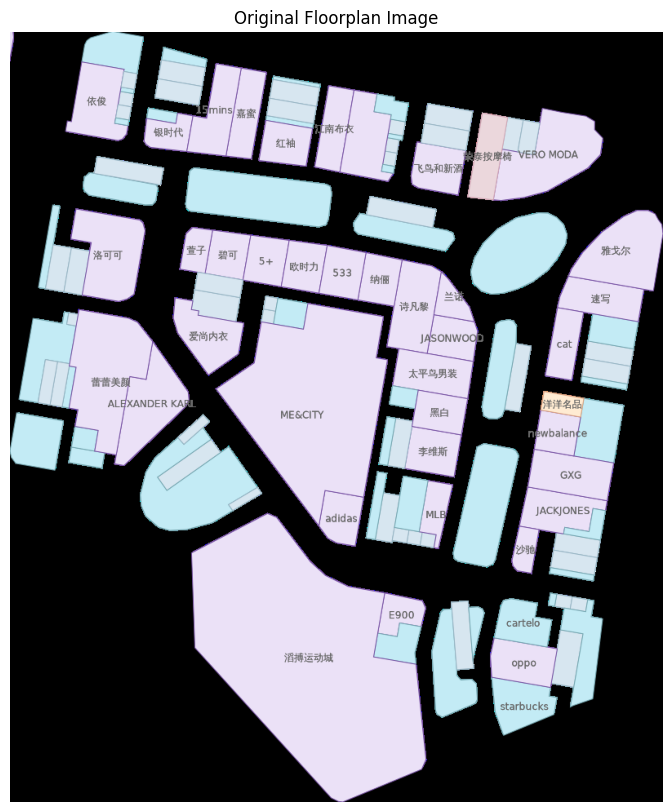

In [22]:
plot_original_image(metadata_root, site, floor)

In [23]:
NUM_POINTS = 2000
EIG_V_DIM = 4

In [24]:
data_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research"  # or appropriate path
metadata_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research/metadata"
floor_info_path = Path(metadata_root)/site/f"F{floor}" / "floor_info.json"
with open(floor_info_path) as f:
    inf = json.load(f)
width_meter, height_meter = inf["map_info"]["width"], inf["map_info"]["height"]
floor_img = Path(metadata_root)/site/f"F{floor}" / "floor_image.png"

In [25]:
def sample_points_from_img_create_layout_graph(floor, site, metadata_root):
    layout_graph = PhysicalLayoutGraph(floor, site, metadata_root, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=7)
    return layout_graph
    dist_matrix = compute_shortest_paths(layout_graph.G, layout_graph.random_points, layout_graph.circles)
    file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\dist_mat_{site}_{floor}_{NUM_POINTS}_num_points.pkl"
    with open(file_path_name, "wb") as f:
        pickle.dump({'dist_matrix': dist_matrix, 'layout_graph': layout_graph}, f)
    pd.to_pickle(dist_matrix, fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl")

In [26]:
layout_graph = sample_points_from_img_create_layout_graph(floor, site, metadata_root)

In [27]:
# file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={layout_graph.k}_just_points.pkl"
# with open(file_path_name, "wb") as f:
#     pickle.dump({'layout_graph': layout_graph}, f)

In [28]:
def create_layout_graph():
    layout_graph = PhysicalLayoutGraph(image_path, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=1)
    file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst.pkl"
    with open(file_path_name, "wb") as f:
        pickle.dump({'layout_graph': layout_graph}, f)
    # pd.to_pickle(dist_matrix, fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl")


def load_layout_graph():
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst.pkl"
    path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={7}_just_points.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    layout_graph = data['layout_graph']

    if not os.path.exists(path):
        raise FileNotFoundError(f"Distance matrix file not found at {path}")
    return layout_graph

In [29]:
# layout_graph = load_layout_graph()

In [30]:
layout_graph.random_points

array([[133,  71],
       [844, 578],
       [669, 455],
       ...,
       [494, 756],
       [ 94, 194],
       [167, 302]], shape=(2000, 2))

In [31]:
def calibrate_points_to_meters(points, image_shape, width_meter, height_meter):
    """
    Convert (y,x) pixel coordinates to (x,y) in meters.
    Parameters:
        points: ndarray of shape (N,2), with (y,x) pixel coordinates.
        image_shape: tuple (H, W) of the image (in pixels).
        width_meter: width of the map in meters (real-world).
        height_meter: height of the map in meters (real-world).
    Returns:
        calibrated: ndarray of shape (N,2), real-world coordinates in meters.
    """
    H, W = image_shape
    ys, xs = points[:, 0], points[:, 1]

    # Flip y-axis to match top-down view, then scale
    xs_m = xs / W * width_meter
    ys_m = (H - ys) / H * height_meter  # flip y

    return np.column_stack((xs_m, ys_m))  # shape: (N, 2)

In [32]:
# def calibrate_points_to_meters(points, image_shape, width_meter, height_meter):
#     """
#     Convert (y,x) pixel coordinates to (x,y) in meters.
    
#     Parameters:
#         points: ndarray of shape (N,2) OR pd.DataFrame.
#                 - If DataFrame with 'x', 'y' columns: Uses those columns directly.
#                 - If Array or DataFrame without labels: Assumes (y, x) order (row, col).
#         image_shape: tuple (H, W) of the image (in pixels).
#         width_meter: width of the map in meters (real-world).
#         height_meter: height of the map in meters (real-world).
        
#     Returns:
#         calibrated: ndarray of shape (N,2), real-world coordinates in meters (x, y).
#     """
#     H, W = image_shape
    
    # # --- Handle Input Type ---
    # if isinstance(points, pd.DataFrame):
    #     # Case A: DataFrame with explicit 'x' and 'y' columns (Best for safety)
    #     if 'x' in points.columns and 'y' in points.columns:
    #         xs = points['x'].values.astype(float)
    #         ys = points['y'].values.astype(float)
    #     else:
    #         # Case B: DataFrame without labels, assume docstring order (x, y)
    #         xs = points.iloc[:, 0].values.astype(float)
    #         ys = points.iloc[:, 1].values.astype(float)
    # else:
    #     # Case C: NumPy Array, assume docstring order (x, y)
    #     xs = points[:, 0]
    #     ys = points[:, 1]

    # # --- Calibration Logic ---
    # # x is horizontal (width), y is vertical (height)
    # xs_m = xs / W * width_meter
    
    # # Flip y-axis: Pixel (0,0) is Top-Left, Real-World (0,0) is usually Bottom-Left
    # ys_m = (H - ys) / H * height_meter 

    # return np.column_stack((xs_m, ys_m))  # Returns (x, y) in meters

In [33]:
# Assume layout_graph.random_points is in (y, x)
image_shape = layout_graph.polygon_mask.shape  # (H, W)
calibrated_points = calibrate_points_to_meters(
    layout_graph.random_points,
    
    image_shape=image_shape,
    width_meter=width_meter,
    height_meter=height_meter
)


In [34]:
layout_graph.random_points = calibrated_points

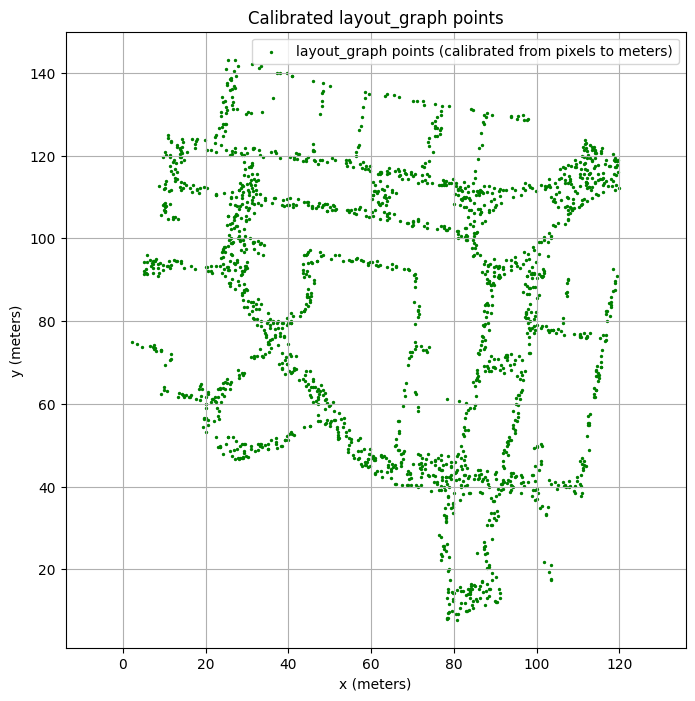

In [35]:
plt.figure(figsize=(8, 8))
plt.scatter(calibrated_points[:, 0], calibrated_points[:, 1], s=2, color="green", label="layout_graph points (calibrated from pixels to meters)")
plt.legend()
plt.title("Calibrated layout_graph points")
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.grid(True)
plt.axis("equal")
plt.show()

# Load signals data

In [36]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path

# --- import the original helper functions from the notebook repo ---  
from data_analysis.io_f import read_data_file    # for reading .txt trace files  
from data_analysis.compute_f import split_ts_seq, compute_step_positions  
from data_analysis.visualize_f import visualize_heatmap  

def build_wifi_fingerprint_df(site: str,
                              floor: int,
                              data_root: str,      # root folder containing train/test .txt files
                              metadata_root: str,  # where floor plan JSON + images are
                              split: str = "train"):
    """
    Build a WiFi fingerprinting DataFrame for a given site & floor,
    by aligning WiFi scans to nearest ground-truth/step positions (x, y).
    """

    # 1. find all trace files for that site & floor
    floor_str = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    folder = Path(data_root) / split / site / floor_str
    txt_files = list(folder.glob("*.txt"))
    if not txt_files:
        raise FileNotFoundError(f"No .txt files found in {folder}")

    rows = []
    all_bssids = set()

    for fpath in txt_files:
        data = read_data_file(str(fpath))
        step_positions = compute_step_positions(data.acce, data.ahrs, data.waypoint)
        wifi_data = data.wifi  # shape: (n_scans, 5) — [timestamp, ..., bssid, rssi]

        if wifi_data.size == 0:
            continue

        # group by unique scan‑timestamp blocks
        for wifi_ds in split_ts_seq(wifi_data, np.unique(wifi_data[:,0].astype(float))):
            ts = float(wifi_ds[0,0])
            # find nearest step position by time
            diffs = np.abs(step_positions[:,0] - ts)
            idx = np.argmin(diffs)
            x, y = step_positions[idx,1], step_positions[idx,2]

            # build a dict: bssid → rssi (mean if multiple within same scan)
            bssid_to_rssi = {}
            for row in wifi_ds:
                bssid = row[2]
                rssi = int(row[3])
                if bssid in bssid_to_rssi:
                    # average if multiple
                    bssid_to_rssi[bssid] = (bssid_to_rssi[bssid] + rssi) / 2
                else:
                    bssid_to_rssi[bssid] = rssi
                all_bssids.add(bssid)

            # append row
            record = {"x": x, "y": y}
            record.update(bssid_to_rssi)
            rows.append(record)

    # 2. build DataFrame
    df = pd.DataFrame(rows)
    df.fillna(-999, inplace=True)  # for missing APs

    print(f"Built fingerprint DF shape: {df.shape} (rows: scans, cols: x,y + {len(all_bssids)} APs)")

    return df

def clean_wifi_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply cleaning similar to your load_filtered_wifi_data:
    - drop columns with all -999
    - drop rows where all signal columns are -999
    - replace -999 → -100
    """
    df = df.copy()
    # drop columns with all -999 (excluding x,y)
    signal_cols = [c for c in df.columns if c not in ("x","y")]
    df = df.drop(columns=[c for c in signal_cols if (df[c] == -999).all()])

    # drop rows where all signal cols are -999
    signal_cols = [c for c in df.columns if c not in ("x","y")]
    mask_all_missing = (df[signal_cols] == -999).all(axis=1)
    df = df.loc[~mask_all_missing].copy()

    # replace -999 with -100
    df[signal_cols] = df[signal_cols].replace(-999, -100)

    return df

# Example usage

data_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research"  # or appropriate path
metadata_root = r"C:/Users/Noa/Documents/GitHub/indoor_localization_research/metadata"
out_path = Path(data_root) / "preprocessed_data_thesis" / f"wifi_fp_{site}_{floor}.csv"

# Save cleaned DF
# df_fp = build_wifi_fingerprint_df(site, floor, data_root, metadata_root, split="train")
# df_clean = clean_wifi_df(df_fp)
# df_clean.to_csv(out_path, index=False)
print("Saved cleaned WiFi fingerprint DF to", out_path)


Saved cleaned WiFi fingerprint DF to C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\wifi_fp_5a0546857ecc773753327266_2.csv


In [37]:
df_clean = pd.read_csv(out_path)

In [38]:

# To plot a heatmap (e.g. WiFi count or mean RSSI) : WiFi count
heat_positions = df_clean[['x','y']].values
heat_values = (df_clean.drop(columns=['x','y']) != -100).sum(axis=1).values

# Load floor plan & metadata for plotting
import json
floor_info_path = Path(metadata_root)/site/f"F{floor}" / "floor_info.json"
with open(floor_info_path) as f:
    inf = json.load(f)
width_meter, height_meter = inf["map_info"]["width"], inf["map_info"]["height"]
floor_img = Path(metadata_root)/site/f"F{floor}" / "floor_image.png"

visualize_heatmap(
    heat_positions, heat_values,
    str(floor_img), width_meter, height_meter,
    colorbar_title="WiFi count",
    title=f"WiFi Sum heatmap — site {site}, floor {floor}",
    show=True
)


In [39]:
# Shuffle all rows
df_clean = df_clean.sample(frac=1, random_state=42)

# reset the index to 0, 1, 2... after shuffling:
df_clean = df_clean.reset_index(drop=True)

## define signal data into locations and signals

In [40]:
df_clean.shape

(2268, 1967)

In [41]:
signals_locations_df = df_clean.loc[:, ["x", "y"]]
signals_df = df_clean.drop(columns=["x", "y"])

In [42]:
signals_locations_df.head()

,x,y
0,39.469775,119.940822
1,30.295768,84.945515
2,88.053609,21.655850
3,46.206460,56.107524
4,106.709890,103.974396


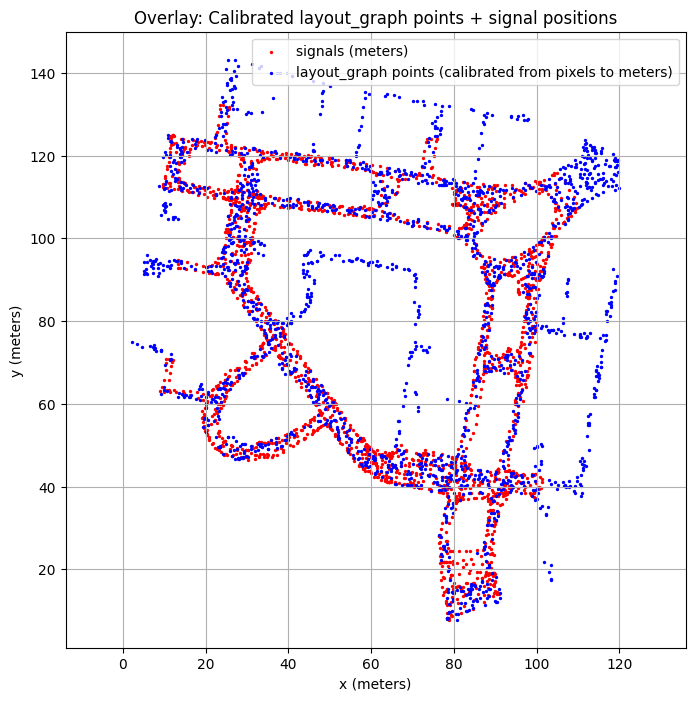

In [43]:
plt.figure(figsize=(8, 8))
plt.scatter(signals_locations_df["x"], signals_locations_df["y"], s=2, color="red", label="signals (meters)")
plt.scatter(calibrated_points[:, 0], calibrated_points[:, 1], s=2, color="blue", label="layout_graph points (calibrated from pixels to meters)")
plt.legend()
plt.title("Overlay: Calibrated layout_graph points + signal positions")
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.grid(True)
plt.axis("equal")
plt.show()

In [44]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def slice_points_near_signals(layout_points, signal_points, max_dist=3.0):
    """
    Keep only layout_graph points that have a signal point nearby.

    layout_points: (N,2) array of layout_graph.random_points (meters)
    signal_points: (M,2) array of signal positions (meters)
    max_dist: distance threshold (e.g., 3 meters)

    Returns:
        filtered_layout_points
        mask (boolean mask of kept points)
    """

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(signal_points)
    distances, _ = nbrs.kneighbors(layout_points)

    mask = distances[:, 0] <= max_dist
    return layout_points[mask], mask


In [45]:
layout_graph.random_points = pd.DataFrame(layout_graph.random_points, columns=["x","y"])

In [46]:
filtered_pts, mask = slice_points_near_signals(
    layout_graph.random_points,
    signals_locations_df,
    max_dist=2.0   # tune this (2-5m usually works)
)


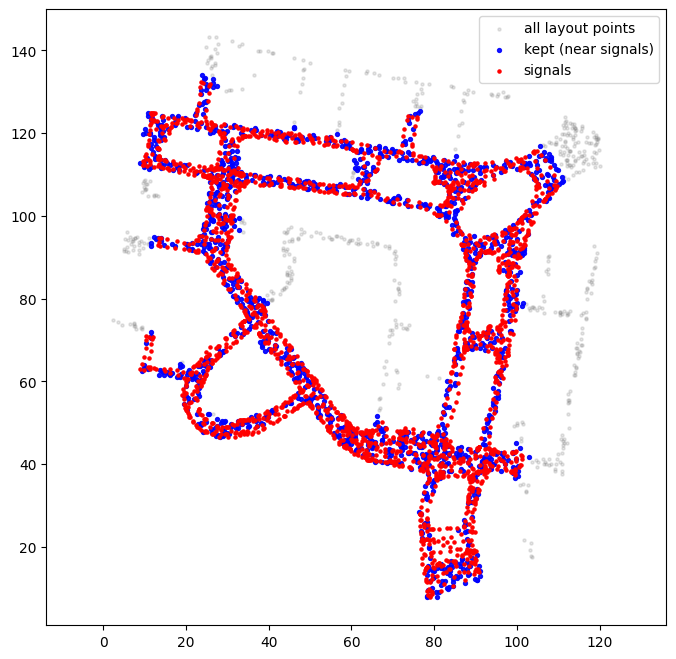

In [47]:
plt.figure(figsize=(8,8))

plt.scatter(layout_graph.random_points.iloc[:,0], 
            layout_graph.random_points.iloc[:,1], 
            s=5, c='gray', alpha=0.2, label='all layout points')

plt.scatter(filtered_pts.iloc[:,0], filtered_pts.iloc[:,1], 
            s=8, c='blue', alpha=0.9, label='kept (near signals)')

plt.scatter(signals_locations_df.iloc[:,0], signals_locations_df.iloc[:,1], 
            s=5, c='red', label='signals')

plt.legend()
plt.axis('equal')
plt.show()

In [48]:
print(f"{len(filtered_pts)} left out of {len(layout_graph.random_points )} total random sampled original points")
layout_graph.random_points = filtered_pts

1504 left out of 2000 total random sampled original points


In [49]:
layout_graph.random_points["x"].max() 

np.float64(111.07818159305373)

In [50]:
layout_graph.random_points["y"].max() 

np.float64(134.12245635845215)

In [51]:
width_meter

122.40020010253855

In [52]:
height_meter

144.53378858719046

# concat all signals with all random points to 1 df with reseted indeces

In [53]:
all_points = pd.concat([signals_locations_df,layout_graph.random_points] , ignore_index=True)

In [54]:
all_points

,x,y
0,39.469775,119.940822
1,30.295768,84.945515
2,88.053609,21.655850
3,46.206460,56.107524
4,106.709890,103.974396
...,...,...
3767,100.062164,85.587275
3768,32.589053,108.553449
3769,12.087020,115.443301
3770,96.390158,70.582708


## Add labeled signals locations to the random points from layout_graph

In [55]:
# signals
n_labeled = 50
n_validation = 200
n_signals = len(df_clean)
n_random_points_sampled_img = len(layout_graph.random_points)
signals_indices = np.arange(n_signals)
rng = np.random.default_rng(seed=42)
combined_sample = rng.choice(signals_indices, size=n_labeled + n_validation, replace=False)

labeled_indices = combined_sample[:n_labeled]
validation_indices = combined_sample[n_labeled:]

print(f"Labeled indices: {len(labeled_indices)}")
print(f"Validation indices: {len(validation_indices)}")
print(f"Overlap check: {np.intersect1d(labeled_indices, validation_indices)}")

Labeled indices: 50
Validation indices: 200
Overlap check: []


In [56]:
labeled_indices

array([2147, 1342,  886,  908,   66, 1091,  214,  354,  285,  204,  822,
        190, 1363,  475, 1213, 1324, 1735,  591, 1183,  996, 1190, 1927,
        274, 1617, 1448,  967,  194, 1846,  506,  840, 1701, 1002, 1618,
        569, 1138,  244, 2220, 1413, 1549,  586,   15, 1422, 1609, 1780,
       1392,  758,  974, 1892,  983, 1401])

In [57]:
n_random_points_sampled_img = len(layout_graph.random_points)

In [58]:
n_random_points_sampled_img

1504

In [59]:
all_points.iloc[labeled_indices]

,x,y
2147,92.841394,38.203697
1342,34.290455,77.190920
886,32.941338,106.977770
908,62.472139,47.173133
66,101.608170,93.137250
1091,44.655199,54.954362
214,59.405331,47.703342
354,98.092514,85.981125
285,83.644594,42.497279
204,21.453134,56.932335


In [60]:
# add labeled singals to the random points
all_points.iloc[labeled_indices]

,x,y
2147,92.841394,38.203697
1342,34.290455,77.190920
886,32.941338,106.977770
908,62.472139,47.173133
66,101.608170,93.137250
1091,44.655199,54.954362
214,59.405331,47.703342
354,98.092514,85.981125
285,83.644594,42.497279
204,21.453134,56.932335


In [61]:
all_points.iloc[-n_random_points_sampled_img:]

,x,y
2268,10.863018,124.170448
2269,88.434145,15.310783
2270,69.615114,42.104652
2271,28.152046,88.649432
2272,77.877127,39.042496
...,...,...
3767,100.062164,85.587275
3768,32.589053,108.553449
3769,12.087020,115.443301
3770,96.390158,70.582708


In [62]:
rnd_pnt = all_points.iloc[-n_random_points_sampled_img:]
lbld_sig = all_points.iloc[labeled_indices]

In [63]:
random_points_with_labeled_signals = pd.concat([rnd_pnt, lbld_sig], axis=0)

In [64]:
all_points.iloc[labeled_indices]

,x,y
2147,92.841394,38.203697
1342,34.290455,77.190920
886,32.941338,106.977770
908,62.472139,47.173133
66,101.608170,93.137250
1091,44.655199,54.954362
214,59.405331,47.703342
354,98.092514,85.981125
285,83.644594,42.497279
204,21.453134,56.932335


In [65]:
a = all_points.iloc[-n_random_points_sampled_img:].index
intersection = np.intersect1d(labeled_indices, a)

if len(intersection) == 0:
    print("✅ Success: No intersection found. The sets are perfectly disjoint.")
else:
    print(f"⚠️ Warning: Found {len(intersection)} overlapping indices!")
    print(f"Overlapping indices: {intersection}")

✅ Success: No intersection found. The sets are perfectly disjoint.


In [66]:
random_points_with_labeled_signals.loc[labeled_indices]

,x,y
2147,92.841394,38.203697
1342,34.290455,77.190920
886,32.941338,106.977770
908,62.472139,47.173133
66,101.608170,93.137250
1091,44.655199,54.954362
214,59.405331,47.703342
354,98.092514,85.981125
285,83.644594,42.497279
204,21.453134,56.932335


In [67]:
# NOTE - those points are the random points from the image plus the labeled signals
layout_graph.random_points = random_points_with_labeled_signals

In [68]:
random_points_with_labeled_signals.shape

(1554, 2)

In [69]:
rnd_pnts_indx = random_points_with_labeled_signals.index[~random_points_with_labeled_signals.index.isin(labeled_indices)]

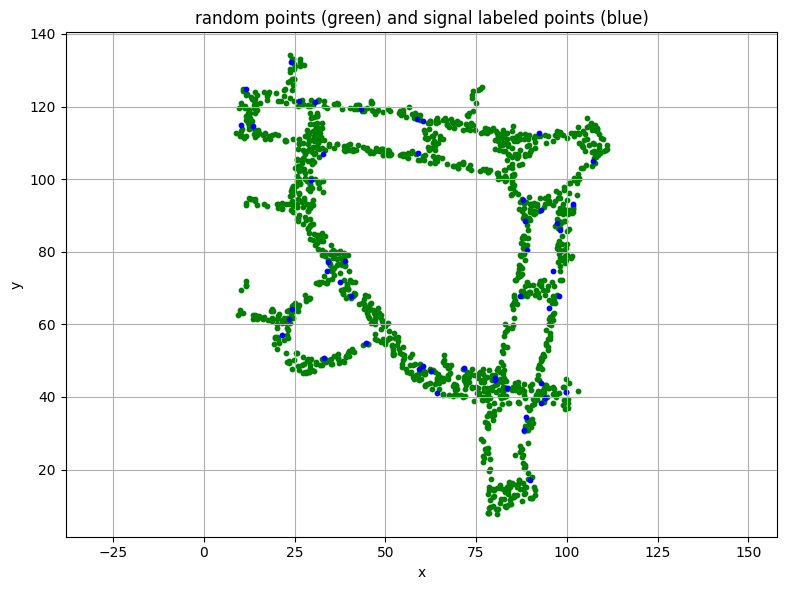

In [70]:
# Assuming df has columns: 'x', 'y', 'signal'
plt.figure(figsize=(8, 6))
plt.scatter(random_points_with_labeled_signals.loc[rnd_pnts_indx]['x'], random_points_with_labeled_signals.loc[rnd_pnts_indx]['y'],c="green", s=10)
plt.scatter(random_points_with_labeled_signals.loc[labeled_indices]['x'], random_points_with_labeled_signals.loc[labeled_indices]['y'],c="blue", s=10)


# Add colorbar to show signal values
# plt.colorbar(sc, label='Signal Strength')

# Axis labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('random points (green) and signal labeled points (blue)')

plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Create signal graph

In [71]:
signal_graph = SignalGraph(signals_df, embedding_dim=EIG_V_DIM, k_nearest=7)

SIG: 1114.5


In [72]:
signal_graph._compute_embedding(EIG_V_DIM)

In [73]:
signal_graph.embedding.shape

(2268, 4)

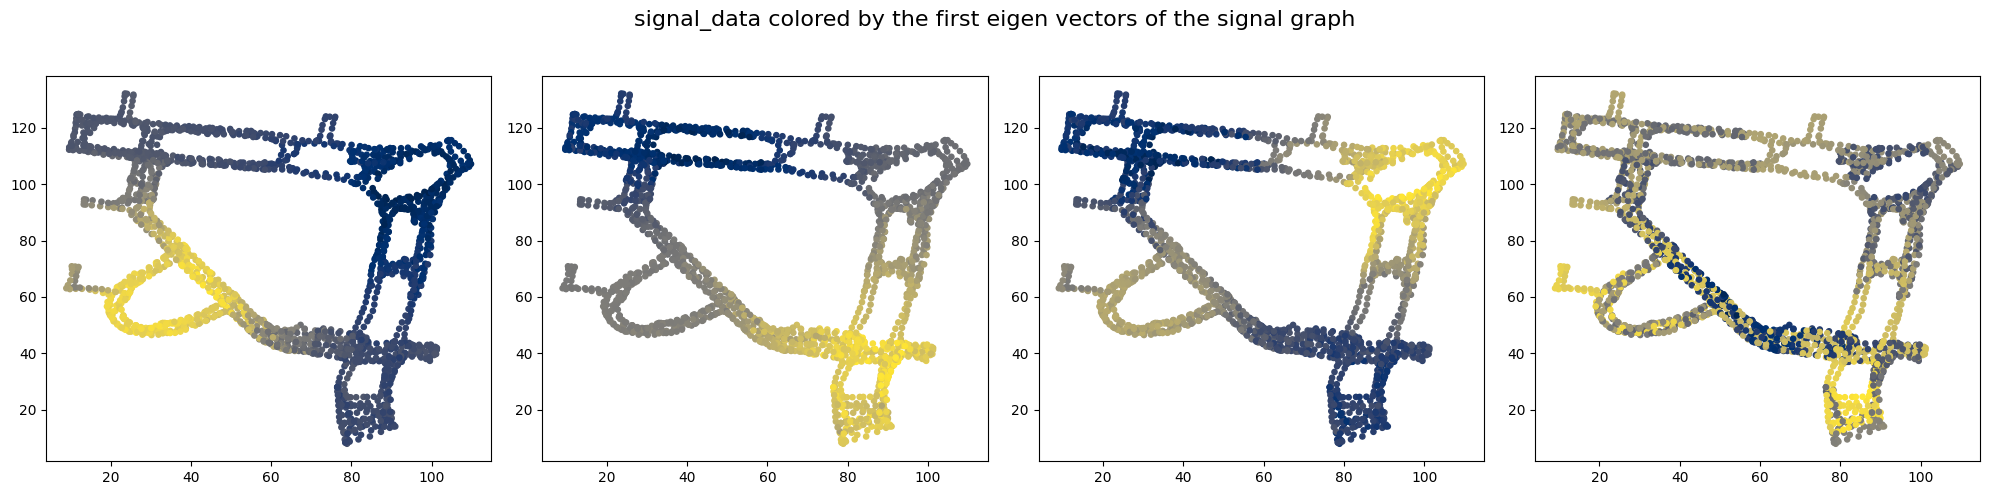

In [74]:
fig,axs = plt.subplots(1,EIG_V_DIM,figsize = (20,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(signals_locations_df["x"],signals_locations_df["y"],c = signal_graph.embedding[:,i],s = 14,cmap = 'cividis')


# Add a title to the entire figure
fig.suptitle("signal_data colored by the first eigen vectors of the signal graph", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.show()

# Area Graph Build

In [75]:
layout_graph._build_graph()

width 122.40020010253855
height 144.53378858719046
Building graph for 1554 nodes. Checking mask constraints...
✅ Created Soft-Wall Graph: 1554 nodes, 270242 edges


In [76]:
file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={layout_graph.k}_graph_new_code.pkl"
with open(file_path_name, "wb") as f:
    pickle.dump({'layout_graph': layout_graph}, f)

# Load LAyout Graph

In [77]:
k = layout_graph.k
def load_layout_graph():
    k = 7
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst.pkl"
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={layout_graph.k}_graph_lastversion.pkl"
    path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={k}_graph_lastversion.pkl"
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\layout_graph_site-{site}_floor-{floor}_NUMPOINTS_{NUM_POINTS}_inst_k={k}_graph_with_labeled.pkl"
    with open(file_path_name, "rb") as f:
        data = pickle.load(f)
    layout_graph = data['layout_graph']

    if not os.path.exists(file_path_name):
        raise FileNotFoundError(f"Distance matrix file not found at {file_path_name}")
    return layout_graph

# layout_graph = load_layout_graph()

In [78]:
layout_graph._compute_adjacency()
layout_graph._compute_embedding()

SIG: 737.0
5


In [79]:
layout_graph.embedding.shape

(1554, 4)

In [80]:
layout_graph.random_points.shape

(1554, 2)

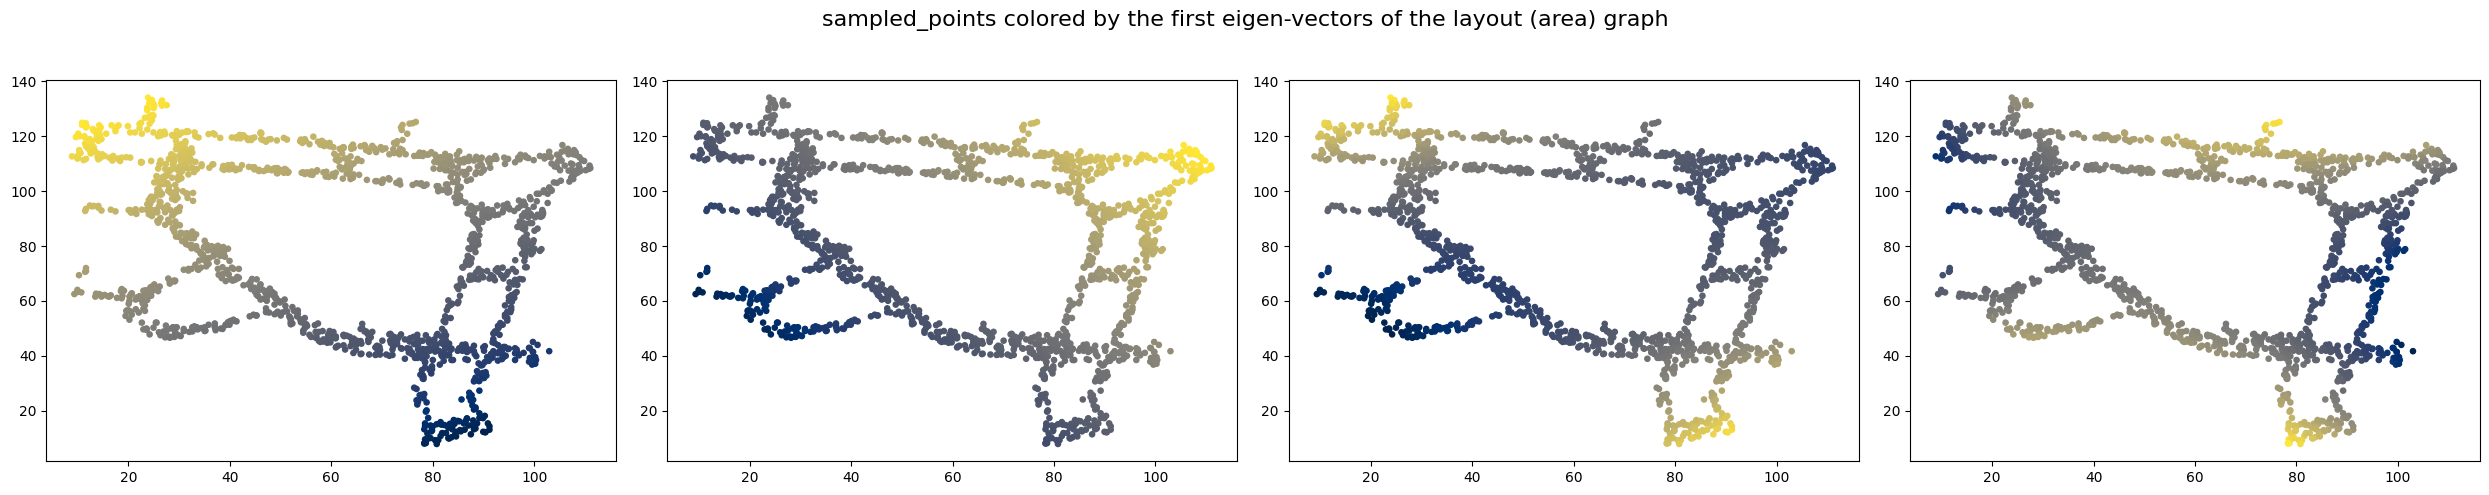

In [81]:
# EIGHEN VECTORS AREA
fig,axs = plt.subplots(1,EIG_V_DIM,figsize = (25,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(layout_graph.random_points["x"],layout_graph.random_points["y"],c = layout_graph.embedding[:,i],s = 14,cmap = 'cividis')

# Add a title to the entire figure
fig.suptitle("sampled_points colored by the first eigen-vectors of the layout (area) graph", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.show()


# SSL 

In [82]:
matcher = ManifoldMatcherSSL()
phi_s, centered_A, C, calib_phi_s = matcher.fit(layout_graph, signal_graph, labeled_indices)

phi_S_dim :(50, 4), A_dim:(50, 2), C dim (4, 2), 
[[ -875.96157972  -370.81100132]
 [  868.7993475  -1348.13247632]
 [  411.86798216   124.12987065]
 [  -63.07534786  -119.87594652]]


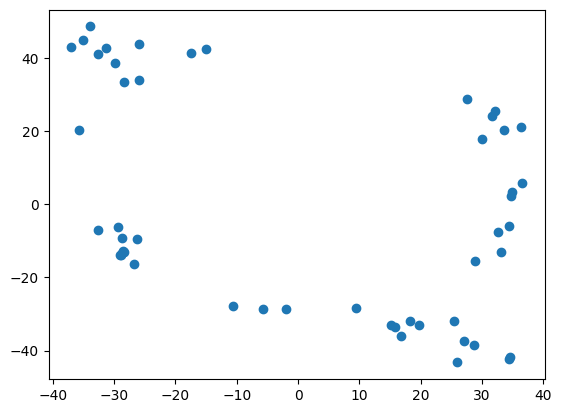

In [83]:
plt.scatter(phi_s @ C[:,0], phi_s @ C[:,1]) 


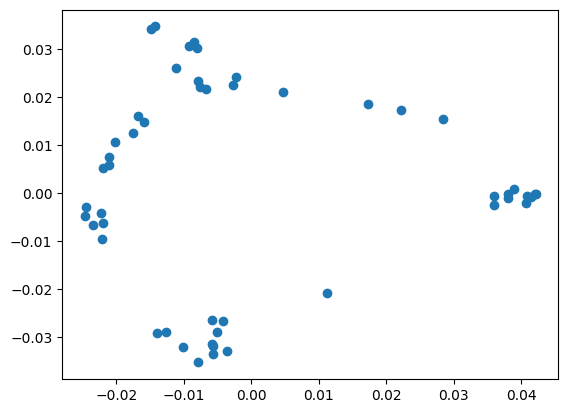

In [84]:
plt.scatter(phi_s[:,0], phi_s[:,1]) 



In [85]:
layout_graph.embedding.shape

(1554, 4)

In [86]:
signal_graph.embedding.shape

(2268, 4)

In [87]:
# Define validation indices (e.g., indices from 20 to 29)
# Make sure these indices are not in labeled_indices

# Important: Add a check to ensure validation_indices do not overlap with labeled_indices
if any(i in labeled_indices for i in validation_indices):
    raise ValueError("Validation indices overlap with labeled indices.")

# Extract signal data and true layout locations for validation points
# validation_data = points_with_signals_df.iloc[validation_indices].copy()
validation_signal_data = signals_df.iloc[validation_indices]
validation_true_real_locations = signals_locations_df.iloc[validation_indices]
validation_signal_data.shape
# Predict locations for the validation signal data
predicted_locations_validation_SSL = matcher.predict(validation_indices)

In [88]:
type(validation_true_real_locations)

pandas.core.frame.DataFrame

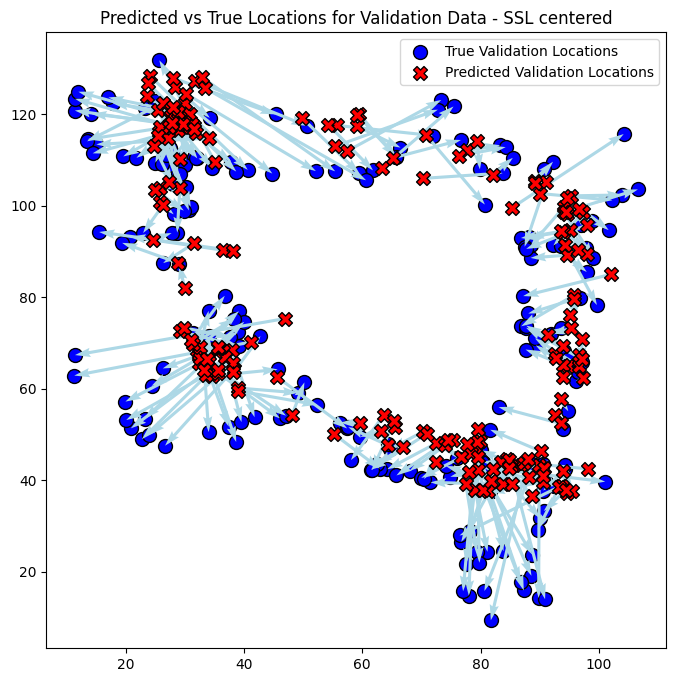

In [89]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations.iloc[:, 0] - predicted_locations_validation_SSL[:, 0]
dy = validation_true_real_locations.iloc[:, 1] - predicted_locations_validation_SSL[:, 1]

# Draw arrows
plt.quiver(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.005)

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - SSL centered")
plt.show()

# MANIFOLD MATCHER

In [90]:
manifold = ManifoldMatcher(layout_graph, signal_graph)
phi_S, C_mat, calibrated_phi_s_labeled = manifold.fit(labeled_indices)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
phi_S_dim :(50, 4),phi_A_dim:(50, 4), 


In [91]:
#Compute the full calibrated signal embedding for all points
calibrated_phi_s = signal_graph.embedding @ C_mat

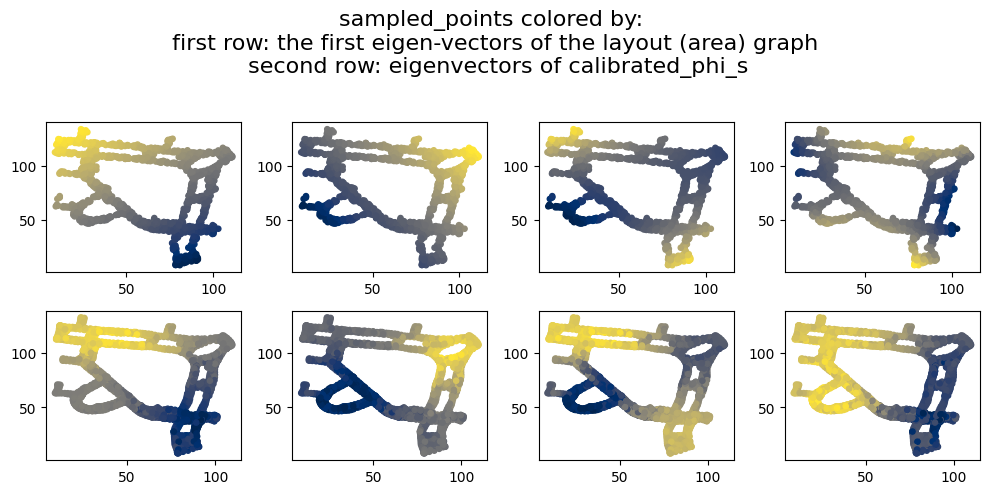

In [92]:
# EIGHEN VECTORS AREA
fig,axs = plt.subplots(2,4,figsize = (10,5))
for i,ax in enumerate(axs.flatten()[0:4]):
    ax.scatter(layout_graph.random_points["x"],layout_graph.random_points["y"],c = layout_graph.embedding[:,i],s = 14,cmap = 'cividis')

for i,ax in enumerate(axs.flatten()[4:8]):
    ax.scatter(signals_locations_df["x"],signals_locations_df["y"],c = calibrated_phi_s[:,i],s = 14,cmap = 'cividis')
# Add a title to the entire figure
fig.suptitle("sampled_points colored by: \n first row: the first eigen-vectors of the layout (area) graph \n second row: eigenvectors of calibrated_phi_s", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.show()

In [93]:
# print( "min vec1", np.min(layout_graph.embedding[:, 0]))
# print( "min vec2", np.min(layout_graph.embedding[:, 1]))
# print( "min vec3", np.min(layout_graph.embedding[:, 2]))
# print("-----------------------")
# print( "max vec1", np.max(layout_graph.embedding[:, 0]))
# print( "max vec2", np.max(layout_graph.embedding[:, 1]))
# print( "max vec3", np.max(layout_graph.embedding[:, 2]))
# print("=++++++++++++++++++++++++++++++")
# print( "min vec1", np.min(calibrated_phi_s[:, 0]))
# print( "min vec2", np.min(calibrated_phi_s[:, 1]))
# print( "min vec3",np.min(calibrated_phi_s[:, 2]))
# print("-----------------------")
# print( "max vec1", np.max(calibrated_phi_s[:, 0]))
# print( "max vec2", np.max(calibrated_phi_s[:, 1]))
# print( "max vec3",np.max(calibrated_phi_s[:, 2]))


In [94]:
# Important: Add a check to ensure validation_indices do not overlap with labeled_indices
if any(i in labeled_indices for i in validation_indices):
    raise ValueError("Validation indices overlap with labeled indices.")

# Extract signal data and true layout locations for validation points
# validation_data = layout_graph.random_points.loc[validation_indices].copy()
# validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
# validation_true_real_locations = validation_data[['x', 'y']].values
validation_signal_data = signals_df.iloc[validation_indices]
validation_true_real_locations = signals_locations_df.iloc[validation_indices]
# validation_true_real_locations = pd.DataFrame(validation_true_real_locations)
validation_signal_data.shape

(200, 1965)

In [95]:
validation_signal_data

,7e8ea22e8ebf91a2c2887c78c709971b22e4a8f1,36d6ef88fa9f134994420eb51b011e6bd73beddd,849955db4cb21ba4003b71e5ce616a4fbf3f68e9,3d8e9fd3c6263b10ad2e1602ea2a57e7cb305aea,e0569c95a2a6f68fe59775a63d071094cd98de65,eb5a1eee1abef853de4844a4ffb945c5f0a55523,4f67f7af8fd4bc0be4792ce1759e9567769fc1a2,8862d0629fd543a489e72c0b4f22b6f9331f42e3,5ff84d7218b7adb864c66a82454aff0d0104508a,fc230ca97bc6bd2969b2194cc896000e972d5542,...,3efea9d2815861aa45ecbfce796ca4441d3a5262,37d2d1d84e3ce194aabbaf988f928c583f52e040,e941d2a6e4f59369fc7acc1e0c5aff1e4f02f182,a98cc13d929540f03aa57c30b61f3e7cf86c6453,3911d7e134339c8c5c52ac88dd77c382421251f1,938f8e1845eb9c1fbff3156b68d27d62a7403afb,a3277f9bdc8b4ff4d84cd78850f554f3c19597f0,460a0aa0ab3e153627a924b4b8564262bf39ceab,1cba90c322fccbce36acd5a9a576813a3d648e8e,4ab1f8a3cf9eba2bb4e5a6c4bca01f3135560462
126,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
397,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
1700,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
1044,-67.0,-56.0,-56.0,-56.0,-56.0,-76.0,-56.0,-56.0,-62.0,-52.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
271,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-92.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
918,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-87.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
920,-90.0,-100.0,-100.0,-100.0,-78.0,-90.0,-100.0,-86.0,-79.0,-87.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
1009,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-93.0,-100.0,-93.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0


In [96]:
# Predict locations for the validation signal data
predicted_locations_validation_manifold2 = manifold.predict2(validation_indices, 3)

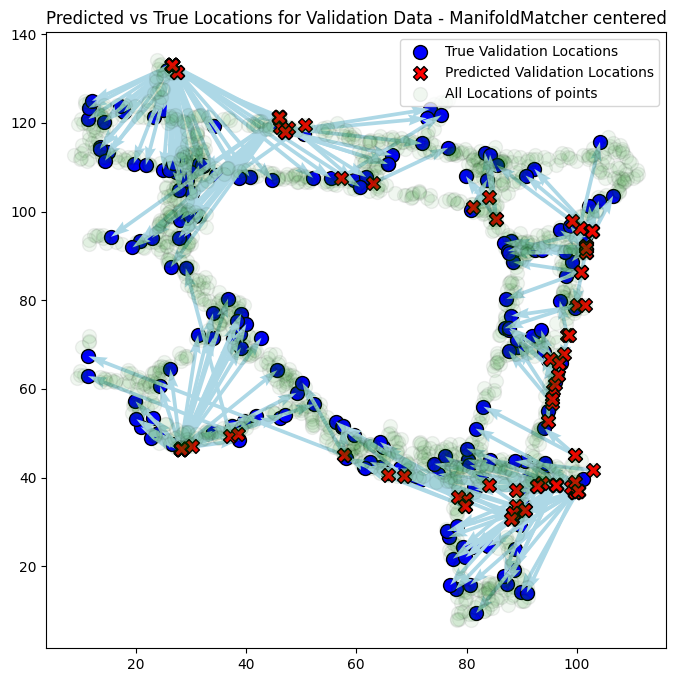

In [97]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations['x'].values - predicted_locations_validation_manifold2['x'].values
dy = validation_true_real_locations['y'].values - predicted_locations_validation_manifold2['y'].values

# Draw arrows
plt.quiver(predicted_locations_validation_manifold2.iloc[:, 0], predicted_locations_validation_manifold2.iloc[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.006)

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_manifold2.iloc[:, 0], predicted_locations_validation_manifold2.iloc[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.scatter(layout_graph.random_points.iloc[:, 0], layout_graph.random_points.iloc[:, 1], color='green', s=100, label="All Locations of points", marker='o', edgecolor='black', alpha=0.06)


plt.legend()
plt.title("Predicted vs True Locations for Validation Data - ManifoldMatcher centered")
plt.show()

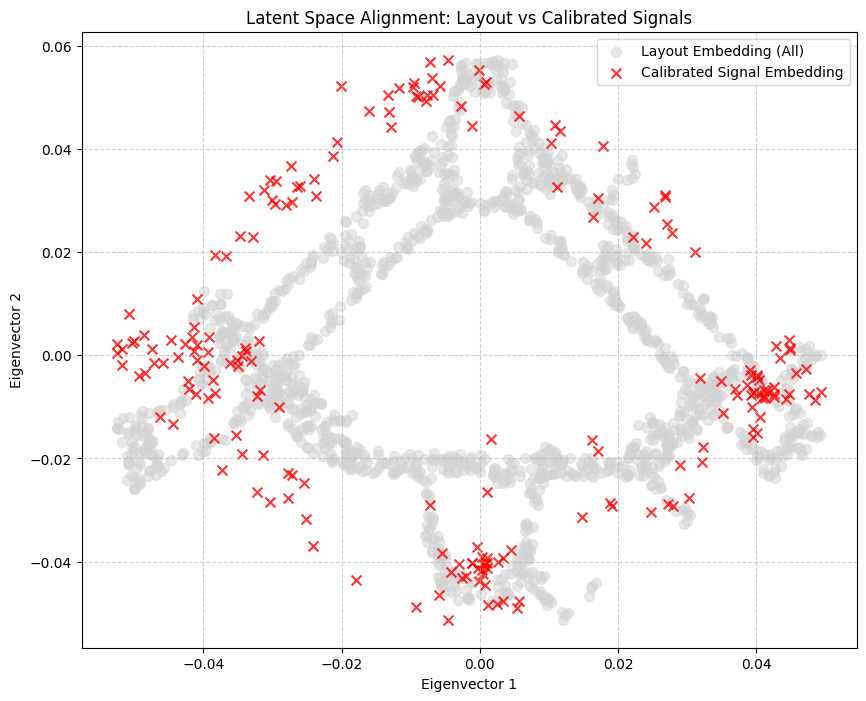

In [98]:
import matplotlib.pyplot as plt

def plot_embedding_alignment(layout_graph, calibrated_phi_s):
    plt.figure(figsize=(10, 8))
    
    # 1. ציור כל נקודות הלייאאוט במרחב ה-Embedding (בצבע אפור/ירוק בהיר)
    plt.scatter(layout_graph.embedding[:, 0], layout_graph.embedding[:, 1], 
                c='lightgray', alpha=0.5, label='Layout Embedding (All)', s=50)
    
    # 2. ציור ה-Embedding המכויל של הסיגנלים (התחזית במרחב הלטנטי)
    plt.scatter(calibrated_phi_s[:, 0], calibrated_phi_s[:, 1], 
                c='red', marker='x', alpha=0.8, label='Calibrated Signal Embedding', s=50)
    
    plt.title("Latent Space Alignment: Layout vs Calibrated Signals")
    plt.xlabel("Eigenvector 1")
    plt.ylabel("Eigenvector 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# הפעלה (בהנחה שאת בתוך המחלקה או שיש לך גישה לאובייקטים)
plot_embedding_alignment(layout_graph, manifold.S_stretched)

In [99]:
# Predict locations for the validation signal data
predicted_locations_validation_manifold = manifold.predict(validation_signal_data, 3)

-----min---------
-0.040170869002445236 -0.052551241491438416
-0.034897050144553035 -0.051285090420994876
-0.04232238544794514 -0.046947689348432395
-------max-------
0.04531406258537398 0.04942186823865941
0.03993363276370897 0.05731191156888146
0.03633595208066224 0.07168847432938567


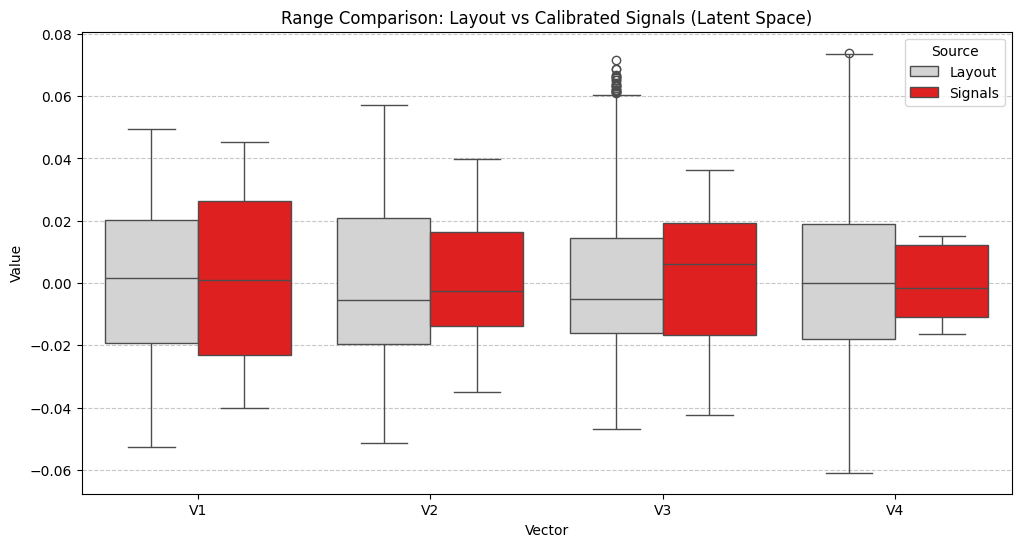

In [100]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_range_comparison(layout_embedding, calibrated_phi_s):
    num_vecs = calibrated_phi_s.shape[1]
    
    # הכנת הנתונים לפורמט של Seaborn
    data = []
    for i in range(num_vecs):
        for val in layout_embedding[:, i]:
            data.append({'Vector': f'V{i+1}', 'Value': val, 'Source': 'Layout'})
        for val in calibrated_phi_s[:, i]:
            data.append({'Vector': f'V{i+1}', 'Value': val, 'Source': 'Signals'})
    
    df = pd.DataFrame(data)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Vector', y='Value', hue='Source', data=df, palette={'Layout': 'lightgray', 'Signals': 'red'})
    plt.title("Range Comparison: Layout vs Calibrated Signals (Latent Space)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# הרצה
plot_range_comparison(layout_graph.embedding[:, :4], manifold.calibrated_phi_s[:, :4])

In [992]:
print(pd.DataFrame(D).shape)

(200, 1608)


In [993]:
layout_graph.embedding.shape

(1608, 4)

In [994]:
pd.DataFrame(manifold.calibrated_phi_s)

,0,1,2,3
0,-0.020839,0.017851,-0.002968,-0.002055
1,-0.022298,0.017063,-0.004535,-0.002760
2,-0.003860,-0.027035,0.038650,-0.007565
3,0.024423,-0.001958,-0.018158,0.006955
4,-0.028111,0.016302,-0.007927,-0.004889
...,...,...,...,...
195,-0.024305,0.023434,-0.002472,-0.001691
196,-0.011811,0.031260,0.008149,0.004577
197,0.018404,0.021541,0.004062,0.011630
198,-0.006981,0.032926,0.010978,0.006617


In [995]:
pd.DataFrame(layout_graph.embedding)

,0,1,2,3
0,-0.017693,0.023328,0.001349,-0.037741
1,0.023842,-0.011853,0.001210,-0.007079
2,0.000422,-0.019732,0.026868,-0.004081
3,0.046241,-0.014941,-0.055667,-0.018747
4,0.011647,0.032068,0.012232,0.031882
...,...,...,...,...
1603,-0.047613,-0.011686,-0.057116,0.025695
1604,0.009854,0.032780,0.013472,0.026903
1605,0.021373,0.021038,0.000471,0.046193
1606,-0.031008,0.009698,-0.020544,-0.032134


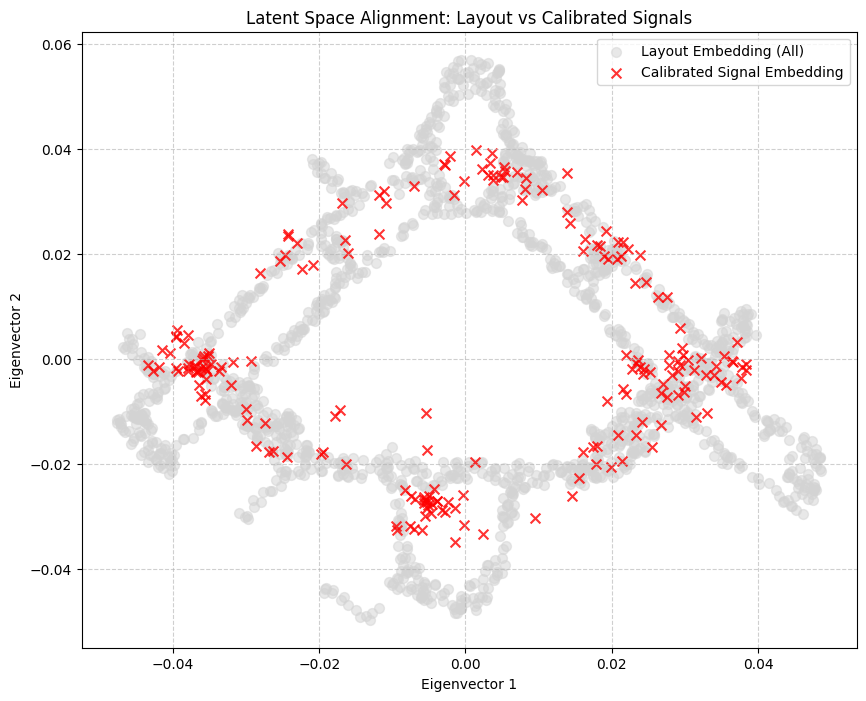

In [996]:
import matplotlib.pyplot as plt

def plot_embedding_alignment(layout_graph, calibrated_phi_s):
    plt.figure(figsize=(10, 8))
    
    # 1. ציור כל נקודות הלייאאוט במרחב ה-Embedding (בצבע אפור/ירוק בהיר)
    plt.scatter(layout_graph.embedding[:, 0], layout_graph.embedding[:, 1], 
                c='lightgray', alpha=0.5, label='Layout Embedding (All)', s=50)
    
    # 2. ציור ה-Embedding המכויל של הסיגנלים (התחזית במרחב הלטנטי)
    plt.scatter(calibrated_phi_s[:, 0], calibrated_phi_s[:, 1], 
                c='red', marker='x', alpha=0.8, label='Calibrated Signal Embedding', s=50)
    
    plt.title("Latent Space Alignment: Layout vs Calibrated Signals")
    plt.xlabel("Eigenvector 1")
    plt.ylabel("Eigenvector 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# הפעלה (בהנחה שאת בתוך המחלקה או שיש לך גישה לאובייקטים)
plot_embedding_alignment(layout_graph, manifold.calibrated_phi_s)

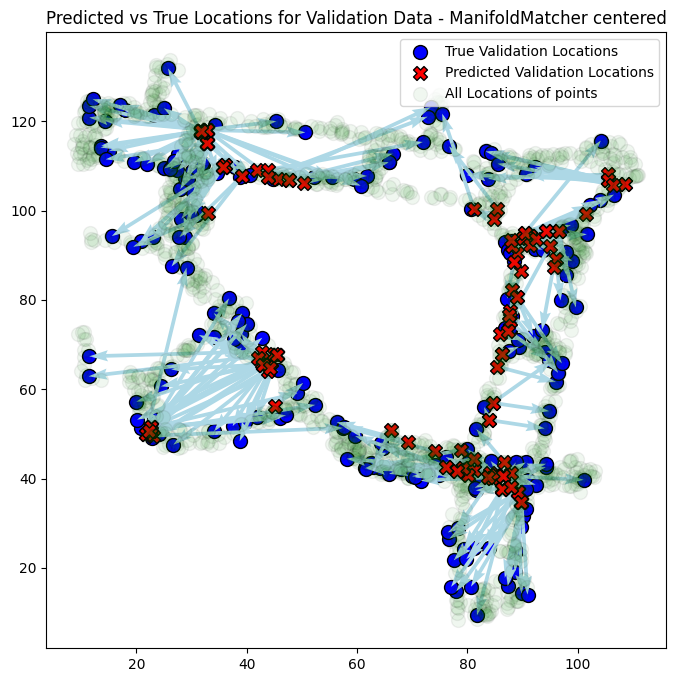

In [990]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations['x'].values - predicted_locations_validation_manifold['x'].values
dy = validation_true_real_locations['y'].values - predicted_locations_validation_manifold['y'].values

# Draw arrows
plt.quiver(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.006)

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.scatter(layout_graph.random_points.iloc[:, 0], layout_graph.random_points.iloc[:, 1], color='green', s=100, label="All Locations of points", marker='o', edgecolor='black', alpha=0.06)


plt.legend()
plt.title("Predicted vs True Locations for Validation Data - ManifoldMatcher centered")
plt.show()

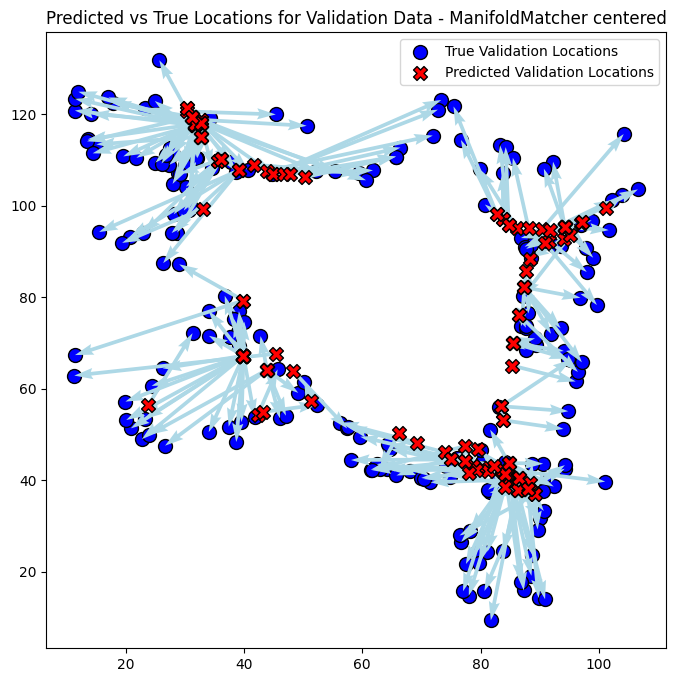

In [855]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations['x'].values - predicted_locations_validation_manifold['x'].values
dy = validation_true_real_locations['y'].values - predicted_locations_validation_manifold['y'].values

# Draw arrows
plt.quiver(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.006)

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - ManifoldMatcher centered")
plt.show()

In [856]:
# --- Usage ---
manifold = ProcrustesManifoldMatcher(layout_graph, signal_graph)
manifold.fit(labeled_indices, labeled_indices)
preds = manifold.predict(validation_indices)

✅ Fitted Rigid Procrustes Alignment (Matched 50 points)


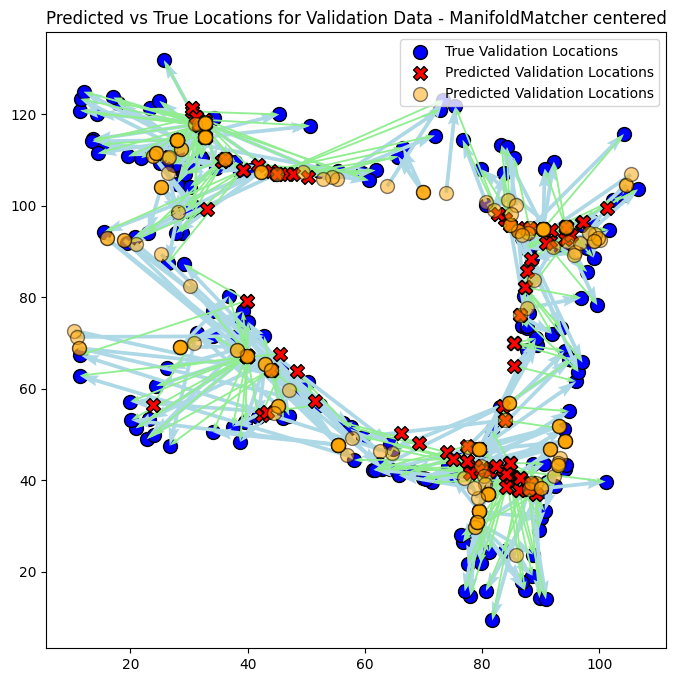

In [857]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
dxx = validation_true_real_locations['x'].values - preds['x'].values
dyy = validation_true_real_locations['y'].values - preds['y'].values

# Draw arrows
plt.quiver(preds.iloc[:, 0], preds.iloc[:, 1], dxx, dyy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.006)

# Compute deltas
dx = validation_true_real_locations['x'].values - predicted_locations_validation_manifold['x'].values
dy = validation_true_real_locations['y'].values - predicted_locations_validation_manifold['y'].values

# Draw arrows
plt.quiver(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightgreen', width=0.003)

plt.scatter(predicted_locations_validation_manifold.iloc[:, 0], predicted_locations_validation_manifold.iloc[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

# Plot the predicted locations of the validation points
plt.scatter(preds.iloc[:, 0], preds.iloc[:, 1], color='orange', s=100, label="Predicted Validation Locations",alpha=0.5, edgecolor='black')

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - ManifoldMatcher centered")
plt.show()

In [116]:
preds.shape

(200, 2)

In [117]:
preds.iloc[:,0].unique().shape

(86,)

In [118]:
preds.iloc[:,1].unique().shape

(87,)

In [119]:
# import networkx as nx

# # Check if the graph is connected
# is_connected = nx.is_connected(layout_graph.G)
# print(f"Is Layout Graph connected? {is_connected}")

# if not is_connected:
#     print(f"Number of connected components: {nx.number_connected_components(layout_graph.G)}")
#     # Keep only the largest component (The Main Floor)
#     largest_cc = max(nx.connected_components(layout_graph.G), key=len)
    
#     # Filter your random_points DF to keep only nodes in the largest component
#     valid_indices = list(largest_cc)
#     print(f"Keeping {len(valid_indices)} nodes out of {layout_graph.G.number_of_nodes()}")
    
#     # Update the graph points
#     layout_graph.random_points = layout_graph.random_points.iloc[valid_indices].reset_index(drop=True)
    
#     # REBUILD the graph with only these points
#     layout_graph._build_graph() 
#     layout_graph._compute_embedding(EMBEDDING_DIM)
    
#     print("✅ Layout Graph repaired (Islands removed).")

In [120]:
from sklearn.linear_model import Ridge
from scipy.spatial.distance import cdist

class RobustManifoldMatcher:
    def __init__(self, layout_graph, signal_graph):
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph
        self.model = None

    def fit(self, signal_indices, layout_indices, alpha=10.0):
        # alpha=10.0 prevents "flying" points. Increase if points are still wild.
        X = self.signal_graph.embedding[signal_indices]
        Y = self.layout_graph.embedding[layout_indices]
        
        # Train Ridge Regression
        self.model = Ridge(alpha=alpha, fit_intercept=True)
        self.model.fit(X, Y)
        print(f"✅ Trained with Ridge Regression (alpha={alpha})")

    def predict(self, signal_indices_to_predict):
        # 1. Project Signal -> Layout Space
        X_query = self.signal_graph.embedding[signal_indices_to_predict]
        calibrated_embedding = self.model.predict(X_query)
        
        # 2. Find Nearest Neighbors
        dists = cdist(calibrated_embedding, self.layout_graph.embedding, metric='euclidean')
        min_idx = np.argmin(dists, axis=1)
        
        return self.layout_graph.get_points().iloc[min_idx]

# --- Usage ---
matcher_ridge = RobustManifoldMatcher(layout_graph, signal_graph)
matcher_ridge.fit(labeled_indices, train_indices, alpha=10.0)

✅ Trained with Ridge Regression (alpha=10.0)


# MANIFOLD CCA

In [128]:
from sklearn.cross_decomposition import CCA
class ManifoldMatcherCCA:

    def __init__(self, layout_graph= None, signal_graph = None):
        self.fitted = False
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, labeled_indices):

        layout_positions = self.layout_graph.random_points.index.get_indexer(labeled_indices)
    
        # בדיקה: אם יש אינדקס שלא נמצא (יחזיר 1-), נסנן אותו כדי למנוע קריסה
        mask = layout_positions != -1
        print(mask)
        valid_layout_pos = layout_positions[mask]
        valid_labeled_indices = np.array(labeled_indices)[mask]

        # 1. שליפת ה-Embeddings (כפי שעשינו קודם)
        phi_S = self.signal_graph.embedding[valid_labeled_indices]
        phi_A = self.layout_graph.embedding[valid_layout_pos] 

        # 2. אימון CCA - הוא ילמד גם את הסיבוב וגם את המתיחה האופטימלית
        # נשתמש במספר הממדים של ה-Embedding שלך (למשל 4)
        self.cca = CCA(n_components=phi_S.shape[1])
        self.cca.fit(phi_S, phi_A)
        print("✅ CCA Alignment fitted")

    def predict(self, validation_indices):
        # 1. הבאת הסיגנלים החדשים
        predict_sig_pos = self.signal_graph.signal_data.index.get_indexer(validation_indices)
        phi_S_raw = self.signal_graph.embedding[predict_sig_pos]
        
        # 2. טרנספורמציה באמצעות CCA
        # ה-CCA יחזיר את phi_S כשהוא כבר "מתוח" ומסובב להתאמה מקסימלית ללייאאוט
        self.S_aligned = self.cca.transform(phi_S_raw)
        
        # 3. Nearest Neighbor רגיל (בלי מתיחות ידניות!)
        dists = cdist(self.S_aligned, self.layout_graph.embedding, metric='euclidean')
        min_idx = np.argmin(dists, axis=1)
        
        res = self.layout_graph.random_points.iloc[min_idx].copy()
        res.index = validation_indices
        return res

In [129]:
manifoldCCA = ManifoldMatcherCCA(layout_graph, signal_graph)

In [130]:
manifoldCCA.fit(labeled_indices)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
✅ CCA Alignment fitted


In [131]:
predsCCA = manifoldCCA.predict(validation_indices)

In [132]:
predsCCA.shape

(200, 2)

In [133]:
validation_true_real_locations.shape

(200, 2)

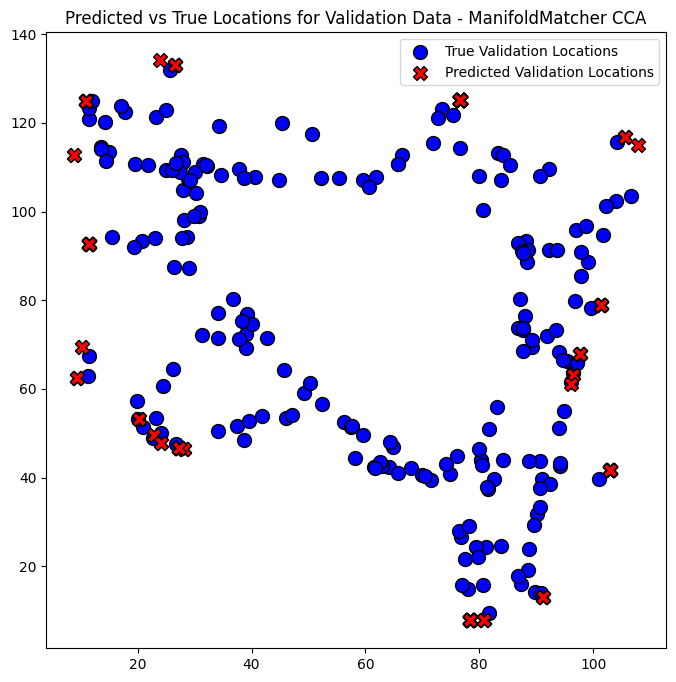

In [134]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
# plt.imshow(layout_graph.polygon_mask, cmap='gray', alpha=0.5)
# plt.imshow(layout_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations.iloc[:, 0], validation_true_real_locations.iloc[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Compute deltas
# dx = validation_true_real_locations['x'].values - predsCCA['x'].values
# dy = validation_true_real_locations['y'].values - predsCCA['y'].values

# Draw arrows
# plt.quiver(predsCCA.iloc[:, 0], predsCCA.iloc[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.006)

# Plot the predicted locations of the validation points
plt.scatter(predsCCA.iloc[:, 0], predsCCA.iloc[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - ManifoldMatcher CCA")
plt.show()

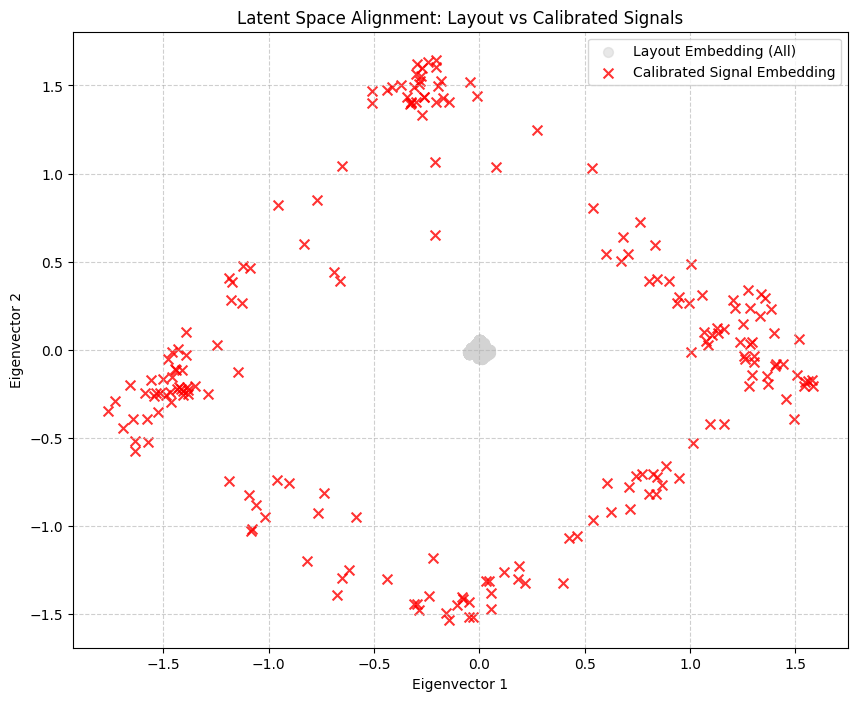

In [135]:
plot_embedding_alignment(layout_graph, manifoldCCA.S_aligned)